In [2]:
# Pacchetto per apertura dati salvati in cartelle zippate
import zipfile

# Pacchetti per analisi dati
#import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import seaborn as sns
import warnings; warnings.simplefilter("ignore")
from functools import reduce
from sklearn.linear_model import LinearRegression
import math
import pytz

# Pacchetti per visualizzazioni grafiche
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
from collections import Counter

<span style="font-size: x-large;">**GESTIONE DATI**</span>  
  
  **<span style="font-size: large;">1. dati davis**

In [3]:
percorso = "./DATI_ORIGINALI/"

# Il percorso va cambiato in funzione di dove sono i vostri dati
nome_file = "Dati_Stazione.zip"
file= str(percorso)+str(nome_file)

with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall(percorso)

stazioni = ["A","B","C"]

for stazione in stazioni:
    
    print("Stazione "+stazione)

    file = percorso+"Dati Meteo - Stazione "+stazione+".txt"
    
    # Di seguito si inizializza una lista vuota, all'interno della quale si va a caricare ogni linea della tabella ".txt".
    # In questo contesto, è importante notare che ogni colonna dei file è separata da spazi bianchi, che devono essere tenuti 
    # in considerazione al momento del caricamento dei dati.
    # Per farlo, si adopera "line.split()", che legge riga per riga la tabella ".txt" (compreso il nome delle colonne) ed 
    # elimina tutti gli spazi tra una colonna e l'altra.

    lista = []
    with open(file, encoding='ISO-8859-1') as f:
        for line in f:
            l = line.split()
            lista.append(l)
    
    # A questo punto, trasformiamo la lista in un DataFrame di pandas, con le colonne nominate come nel file originale.
    df = pd.DataFrame(lista[1:],columns=lista[0])
    
    # Seppur non necessario ai fini delle analisi, con i prossimi due comandi si sistemano le intestazioni delle colonne:
    # 1. Eliminiamo la virgola alla fine dei nomi delle diverse colonne nel file originale (es. "wndSpeed,")
    df.columns = df.columns.str.rstrip(',')    
    # 2. Eliminiamo il carattere "#" di fronte alla parola "Date" della prima colonna ("#Date")
    nome_prima_colonna = df.columns[0][1:]
    df.rename(columns={df.columns[0]: nome_prima_colonna}, inplace=True)
    
    # I dati della stazione C presentano dei caratteri verso la fine dell'intervallo temporale che non sono facilmente decifrati/interpretati da python.
    # Si procede quindi a selezionare solo quelle righe del dataframe della stazione C dove tutte le colonne contengono solo 
    # caratteri alfabetici (a-zA-Z), caratteri numerici (0-9) e il segno meno (-).
    
    if stazione == "C":
        for col in range(df.shape[1]):
            column = df.columns[col]
            mask = df[str(column)].str.contains(r'^[a-zA-Z0-9.-]+$', na=False)
            df = df[mask]
    else:
        pass

#creo colonna Datetime
    day = df['Date'].values; hour = df['Time'].values
    date_final = np.array([datetime.strptime(data + ' ' + ora, "%Y%m%d %H.%M") for data, ora in zip(day, hour)])
    df.insert(2,'Datetime',date_final)
    df.drop(df.columns[:2],axis=1, inplace=True)
            
    df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
                    
#riordina by date
    df = df.sort_values(by='Datetime', ignore_index=True) #ricrea indici di riga da 0 a n-1
    df.set_index(df['Datetime'], inplace=True)
    df.index.name = None
    globals()["df_"+stazione] = df

Stazione A
Stazione B
Stazione C


In [4]:
display(df_A)

,Datetime,Interval,Press,inTemp,outTemp,inHum,outHum,wndSpeed,wndDir,windGust,wGstDir,rainRate,rain,dewpoint,wdChill,heatIndx,ET,totRad,UV
2005-09-22 03:00:00,2005-09-22 03:00:00,30.0,1017.27,22.22,14.28,44.0,76.0,0.447,270.0,2.235,292.5,0.0,0.0,10.1,14.28,14.28,0.0,0.0,0.8
2005-09-22 03:30:00,2005-09-22 03:30:00,30.0,1017.21,22.11,14.11,45.0,76.0,0.447,270.0,3.129,270.0,0.0,0.0,9.94,14.11,14.11,0.0,0.0,0.8
2005-09-22 04:00:00,2005-09-22 04:00:00,30.0,1017.31,22.06,13.94,45.0,76.0,0.447,270.0,2.682,270.0,0.0,0.0,9.78,13.94,13.94,0.0,0.0,0.8
2005-09-22 04:30:00,2005-09-22 04:30:00,30.0,1017.27,21.94,13.94,45.0,76.0,0.0,270.0,1.788,270.0,0.0,0.0,9.78,13.94,13.94,0.0,0.0,0.8
2005-09-22 05:00:00,2005-09-22 05:00:00,30.0,1017.17,21.83,13.89,45.0,76.0,0.447,292.5,2.235,315.0,0.0,0.0,9.73,13.89,13.89,0.0,0.0,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-10-22 11:00:00,2019-10-22 11:00:00,30.0,1023.03,23.83,-73.28,63.0,-99.9,-44.655,-99.9,0.0,-99.9,0.0,0.0,-73.28,-73.28,-73.28,0.0,-99.9,-99.9
2019-10-22 11:30:00,2019-10-22 11:30:00,30.0,1023.07,23.89,-73.28,63.0,-99.9,-44.655,-99.9,0.0,-99.9,0.0,0.0,-73.28,-73.28,-73.28,0.0,-99.9,-99.9
2019-10-22 12:00:00,2019-10-22 12:00:00,30.0,1023.03,23.89,-73.28,63.0,-99.9,-44.655,-99.9,0.0,-99.9,0.0,0.0,-73.28,-73.28,-73.28,0.0,-99.9,-99.9
2019-10-22 12:30:00,2019-10-22 12:30:00,30.0,1022.83,23.89,-73.28,63.0,-99.9,-44.655,-99.9,0.0,-99.9,0.0,0.0,-73.28,-73.28,-73.28,0.0,-99.9,-99.9


**<span style="font-size: large;">Solo dati alle HH:00 o HH:30**

In [5]:
for stazione in stazioni:
    df = globals()["df_"+stazione].copy() #sono dati raw con colonna datetime unica e ordinata per datetime con nuovi indici
    
    globals()["df_"+stazione+"_interval30"] = df[((df.Datetime.dt.minute == 0)|(df.Datetime.dt.minute == 30))&(df.Interval == 30)]
    print(f"Stazione {stazione} " + str( globals()["df_"+stazione+"_interval30"].Interval.min())) #to verify


Stazione A 30.0
Stazione B 30.0
Stazione C 30.0


<span style="font-size: large;">**Filtro temporale Davis**<br>
Dal 2015 al 2016

In [6]:
def get_season(month):
    if 3 <= month <= 5:
        return 'MAM'
    elif 6 <= month <= 8:
        return 'JJA'
    elif 9 <= month <= 11:
        return 'SON'
    else:
        return 'DJF'

for stazione in stazioni:
    print("STAZIONE_"+stazione)
    df = globals()["df_"+stazione+"_interval30"].copy()  #sono dati raw con colonna datetime unica e ordinata per datetime con nuovi indici
    #aggiungo indice di stagione
    df['Stagione'] = df['Datetime'].dt.month.apply(get_season)
    #filtro anni di interesse
    df_year = df[(df["Datetime"].dt.year >= 2015)&(df["Datetime"].dt.year <= 2016)]
    globals()["df_"+stazione+"_year"] = df_year

    print("raw      " + str(globals()["df_"+stazione+"_interval30"].shape[0]))
    print("rimaste  " + str(globals()["df_"+stazione+"_year"].shape[0]))

STAZIONE_A
raw      192033
rimaste  35082
STAZIONE_B
raw      187243
rimaste  34947
STAZIONE_C
raw      85469
rimaste  35083


**<span style="font-size: large;">Dataframe ARPA** <br>
Temperatura, UR, press

In [7]:
percorso = "./DATI_ARPAE/"
files = ['tpavg', 'tpmax', 'tpmin', 'uravg', 'urmax', 'urmin', 'pressure']
for file in files:
    # Eliminiamo le prime 4 righe che sono dati testuali e gli ultimi valori dell'anno precedente
    df = pd.read_csv(percorso+'2015-2016_'+file+'_urbana.csv', encoding='ISO-8859-1',names=['Datetime UTC','Fine validità (UTC)',file],
                        skiprows=4,on_bad_lines='skip')
    # Eliminiamo inoltre le ultime righe che hanno solo dati testuali
    df = df[:-2]
    # Eliminiamo la colonna "Fine validità (UTC)" in quanto disponiamo dell'informazione sulla data già dalla prima colonna.
    # La seconda colonna ci sta solo ad indicare che le misure sono misure di vento orarie (come già noto dal sito web ARPAE).
    df.drop(df.columns[1],axis=1, inplace=True)

    # Trasformiamo la colonna tempo in formato Data Anno-Mese-Giorno ora:minuto (come fatto in precedenza)
    df['Datetime UTC'] = pd.to_datetime(df['Datetime UTC'])
    df[file] = df[file].astype(float) #tofloat

    #converti to local time
    local_timezone = pytz.timezone('Etc/GMT-2')
    df['Datetime'] = df['Datetime UTC'].dt.tz_convert(local_timezone)
    df['Datetime'] = df['Datetime'].dt.tz_localize(None)
    df.set_index(df['Datetime'], inplace=True)
    df.index.name = None
    df.drop(df.columns[0], axis=1, inplace=True)
    #print(str(df.Datetime.min()) + " " + str(df.Datetime.max()))
    #print(df.columns)
    if file == files[0]:
        df_ARPAE = df
    else:
        df_ARPAE = pd.merge(df_ARPAE, df, on='Datetime', suffixes=(None, '_'+file))
df_ARPAE.set_index(df_ARPAE['Datetime'], inplace=True)
df_ARPAE.index.name = None
df_ARPAE.pressure = df_ARPAE.pressure / 100
df_ARPAE

,tpavg,Datetime,tpmax,tpmin,uravg,urmax,urmin,pressure
2015-01-01 01:00:00,-1.6,2015-01-01 01:00:00,-1.5,-1.7,72.0,76.0,70.0,1025.3
2015-01-01 02:00:00,-1.6,2015-01-01 02:00:00,-1.5,-1.8,73.0,79.0,70.0,1025.5
2015-01-01 03:00:00,-1.8,2015-01-01 03:00:00,-1.7,-1.9,80.0,82.0,78.0,1025.9
2015-01-01 04:00:00,-1.8,2015-01-01 04:00:00,-1.7,-1.9,77.0,80.0,71.0,1025.9
2015-01-01 05:00:00,-1.7,2015-01-01 05:00:00,-1.5,-1.9,68.0,72.0,64.0,1025.4
...,...,...,...,...,...,...,...,...
2016-12-31 21:00:00,2.5,2016-12-31 21:00:00,2.8,2.2,70.0,70.0,69.0,1021.1
2016-12-31 22:00:00,2.3,2016-12-31 22:00:00,2.5,2.2,68.0,69.0,65.0,1020.6
2016-12-31 23:00:00,2.1,2016-12-31 23:00:00,2.3,1.9,65.0,66.0,63.0,1020.4
2017-01-01 00:00:00,1.8,2017-01-01 00:00:00,2.0,1.5,62.0,65.0,60.0,1019.9


<span style="font-size: x-large;">**ANALISI DELLA TEMPERATURA**<span style="font-size: x-large;">  

<span style="font-size: large;">**1. Filtro di plausibilità**

In [8]:
tpmax = df_ARPAE.tpmax.max()
tpmin = df_ARPAE.tpmin.min()
urmax = df_ARPAE.urmax.max()
urmin = df_ARPAE.urmin.min()
prmax = df_ARPAE.pressure.max()
prmin = df_ARPAE.pressure.min()
tpmax, tpmin, urmin, urmax, prmax, prmin

(np.float64(37.5),
 np.float64(-3.0),
 np.float64(10.0),
 np.float64(103.0),
 np.float64(1030.1),
 np.float64(967.2))

In [9]:
for stazione in stazioni:
    df = globals()["df_"+stazione+"_year"].copy()
    print(df.shape[0])
    globals()["df_"+stazione+"_year_filt"] = df[(df.outHum <= 100) & (df.outHum >= urmin-1) & 
                                           (df.outTemp >= tpmin-0.05) & (df.outTemp <= tpmax+0.05) & 
                                           (df.Press >= prmin-0.03) & (df.Press <= prmax+0.03)]
    n_ok = globals()["df_"+stazione+"_year_filt"].shape[0]
    print(str(n_ok / df.shape[0] *100) + " " + str(n_ok))
    print("tra -20 e -3 gradi " + str(df[(df.outTemp < tpmin) & (df.outTemp > -70)].shape[0]))
    print("tra 37.5 e 50 gradi " + str(df[(df.outTemp < 50) & (df.outTemp > tpmax)].shape[0]))
    if stazione == 'C':
        print("tra -6 e -3 gradi " + str(df[(df.outTemp < -3) & (df.outTemp > -6)].shape[0]))

35082
93.64061341998746 32851
tra -20 e -3 gradi 0
tra 37.5 e 50 gradi 13
34947
86.61973846109824 30271
tra -20 e -3 gradi 0
tra 37.5 e 50 gradi 8
35083
95.2056551606191 33401
tra -20 e -3 gradi 70
tra 37.5 e 50 gradi 0
tra -6 e -3 gradi 70


  <span style="font-size: large;">**2. Risoluzione variabili**  

In [10]:
for stazione in stazioni:
    print("stazione "+stazione)
    df = globals()["df_"+stazione+"_year_filt"].copy()
    vars = ['outTemp', 'outHum', 'Press']
    for var in vars:
        col = df[var].copy() #filtro anni, risoluzione temp, plausibilita
        col = col.drop_duplicates()
        col = col.sort_values()
        #print(col)
        differences_col = np.diff(col)  # Compute consecutive differences
        #print(differences_col)
        resolution_col = np.min(differences_col) if len(differences_col) > 0 else None
        print(f"{var} Resolution: {resolution_col} units")

stazione A
outTemp Resolution: 0.04999999999999716 units
outHum Resolution: 1.0 units
Press Resolution: 0.029999999999972715 units
stazione B
outTemp Resolution: 0.04999999999999716 units
outHum Resolution: 1.0 units
Press Resolution: 0.029999999999972715 units
stazione C
outTemp Resolution: 0.04999999999999716 units
outHum Resolution: 1.0 units
Press Resolution: 0.029999999999972715 units


<span style="font-size: large;">**3. CONFRONTO TRA STAZIONI DIVERSE**  

Per confrontare i dati di due stazioni, si possono adoperare diversi indici statistici, quali ad esempio:
- Indice di correlazione,
- Mean Error (ME),
- Mean Absolute Error (MAE),
- Root Mean Square Error (RMSE),
- RMSE normalizzato con la media del dataset di riferimento,

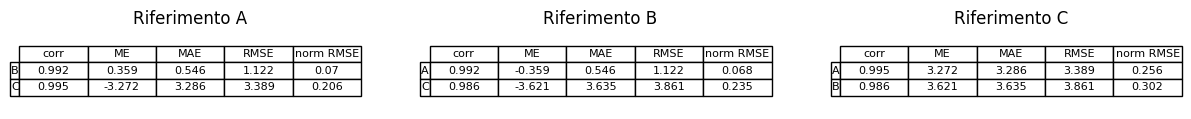

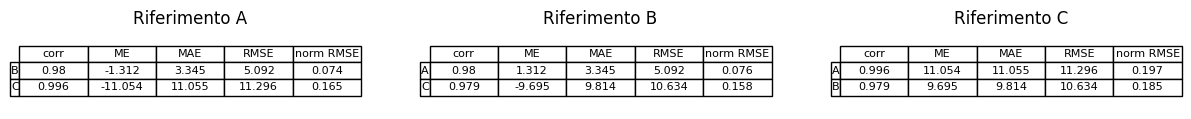

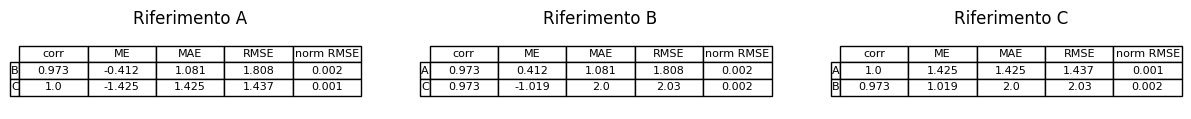

In [11]:
import pandas as pd
import numpy as np

def statistics(var,ref):
    
    CORR = var.corrwith(ref)[0]
    ME = np.mean(np.subtract(var, ref))
    MAE = np.mean(np.abs(np.subtract(var, ref)))
    RMSE = np.sqrt(np.nanmean(np.square(np.subtract(var, ref))))
    nRMSE = RMSE / np.nanmean(ref)
    
    return CORR, ME, MAE, RMSE, nRMSE

def compare_column(ref, var, column_name):
    df = ref.copy()
    df_comp = var.copy()

    #seleziono dove stessa data
    common_index = list((df.index).intersection(df_comp.index))

    df_ref = df.loc[common_index].copy()
    df_to_comp = df_comp.loc[common_index].copy()
    corr,me,mae,rmse,nrmse = statistics(df_to_comp[[column_name]],df_ref[[column_name]])
    return corr,me,mae,rmse,nrmse

stazioni = ['A', 'B', 'C']
vars = ['outTemp', 'outHum', 'Press']
for var in vars:
    fig, axes = plt.subplots(1, 3, figsize=(3 * 5, 1))
    i = 0
    for riferimento in stazioni:
        rows = []
        #print("Riferimento "+riferimento)
        indexes = []
        for stazione in stazioni:
            if stazione != riferimento:
                indexes.append(stazione)
                corr, me, mae, rmse, nrmse = compare_column(globals()["df_"+riferimento+"_year_filt"], globals()["df_"+stazione+"_year_filt"], var)
                rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

        df = pd.DataFrame(rows, index=indexes, columns=['corr', 'ME', 'MAE', 'RMSE', 'norm RMSE'])
        #display(df)

        ax = axes[i]
        i +=1
        ax.axis('off')
        ax.set_title("Riferimento "+riferimento, loc='center')
        table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1)
    plt.savefig('FIGURE/'+var+'_compare_davis.png', dpi=300, bbox_inches='tight')


<span style="font-size: large;">**4. CONFRONTO DIFFERENZE NEL TEMPO DELLE STAZIONI**

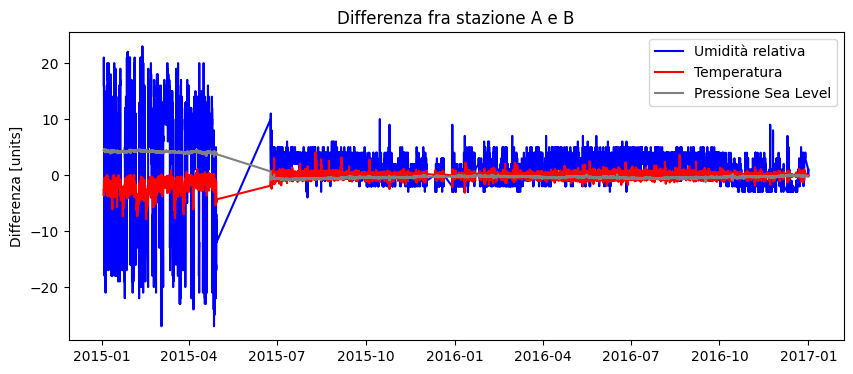

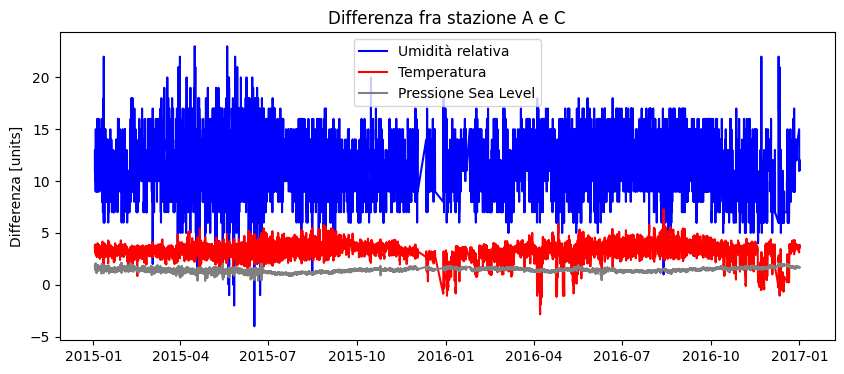

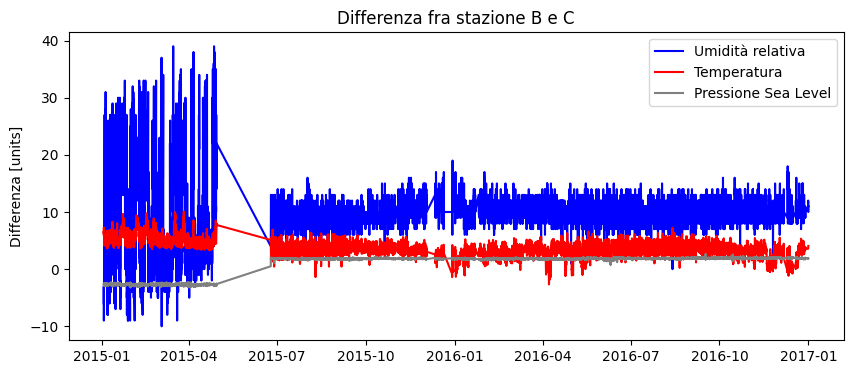

In [12]:
A = globals()["df_A_year_filt"].copy()
B = globals()["df_B_year_filt"].copy()
C = globals()["df_C_year_filt"].copy()

vars = ['outHum','outTemp', 'Press']
colors = ['blue','red', 'grey']
for var in vars:
    df_merged = pd.merge(A, B, on='Datetime', suffixes=('_A', '_B'))
    plt.figure(1, figsize=(10, 4))
    plt.plot(df_merged["Datetime"], np.subtract(df_merged[var+"_A"], df_merged[var+"_B"]), color=colors[vars.index(var)])
    plt.ylabel('Differenza [units]')
    plt.legend(['Umidità relativa', 'Temperatura', 'Pressione Sea Level'])
    plt.title("Differenza fra stazione A e B")
    plt.savefig('FIGURE/B/diff_AB_tempo.png', dpi=300, bbox_inches='tight')

    df_merged = pd.merge(A, C, on='Datetime', suffixes=('_A', '_C'))
    plt.figure(2, figsize=(10, 4))
    plt.plot(df_merged["Datetime"], np.subtract(df_merged[var+"_A"], df_merged[var+"_C"]), color=colors[vars.index(var)])
    plt.ylabel('Differenza [units]')
    plt.legend(['Umidità relativa', 'Temperatura', 'Pressione Sea Level'])
    plt.title("Differenza fra stazione A e C")
    plt.savefig('FIGURE/B/diff_AC_tempo.png', dpi=300, bbox_inches='tight')

    df_merged = pd.merge(B, C, on='Datetime', suffixes=('_B', '_C'))
    plt.figure(3, figsize=(10, 4))
    plt.plot(df_merged["Datetime"], np.subtract(df_merged[var+"_B"], df_merged[var+"_C"]), color=colors[vars.index(var)])
    plt.ylabel('Differenza [units]')
    plt.legend(['Umidità relativa', 'Temperatura', 'Pressione Sea Level'])
    plt.title("Differenza fra stazione B e C")
    plt.savefig('FIGURE/B/diff_BC_tempo.png', dpi=300, bbox_inches='tight')


<span style="font-size: large;">**5. REGRESSIONE LINEARE temp C - media(A,B)**

In [13]:
df_A = globals()["df_A_year_filt"][['Datetime','outTemp','outHum']].copy()
df_B = globals()["df_B_year_filt"][['Datetime','outTemp','outHum']].copy()
df_avgAB = pd.merge(df_A, df_B, on='Datetime', suffixes=('_A', '_B'))
df_avgAB['outTemp'] = (df_avgAB['outTemp_A'] + df_avgAB['outTemp_B'])/2
df_avgAB['outHum'] = (df_avgAB['outHum_A'] + df_avgAB['outHum_B'])/2

def get_season(month):
    if 3 <= month <= 5:
        return 'MAM'
    elif 6 <= month <= 8:
        return 'JJA'
    elif 9 <= month <= 11:
        return 'SON'
    else:
        return 'DJF'

#aggiungo indice di stagione
df_avgAB['Stagione'] = df_avgAB['Datetime'].dt.month.apply(get_season)
df_avgAB

,Datetime,outTemp_A,outHum_A,outTemp_B,outHum_B,outTemp,outHum,Stagione
0,2015-01-02 14:00:00,8.06,51.0,10.67,35.0,9.365,43.0,DJF
1,2015-01-02 14:30:00,8.22,51.0,11.39,32.0,9.805,41.5,DJF
2,2015-01-02 15:00:00,8.39,53.0,12.11,32.0,10.25,42.5,DJF
3,2015-01-02 15:30:00,8.22,55.0,11.67,36.0,9.945,45.5,DJF
4,2015-01-02 16:00:00,7.89,58.0,11.06,39.0,9.475,48.5,DJF
...,...,...,...,...,...,...,...,...
30055,2016-12-31 21:30:00,3.72,77.0,3.83,77.0,3.775,77.0,DJF
30056,2016-12-31 22:00:00,3.61,77.0,3.67,76.0,3.64,76.5,DJF
30057,2016-12-31 22:30:00,3.39,77.0,3.5,76.0,3.445,76.5,DJF
30058,2016-12-31 23:00:00,3.28,76.0,3.28,75.0,3.28,75.5,DJF


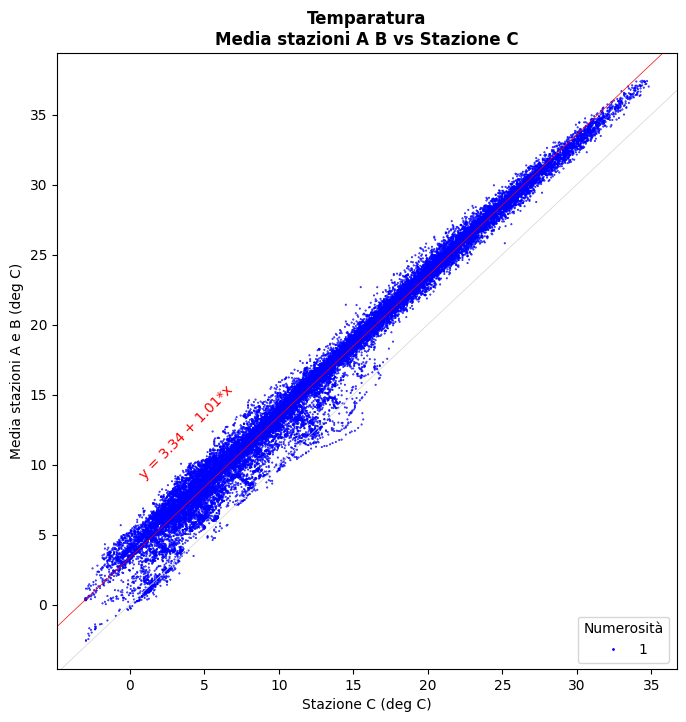

In [14]:
df_C = globals()["df_C_year_filt"][['Datetime','outTemp']]
df_merged = pd.merge(df_C, df_avgAB, on='Datetime', suffixes=('_C', '_avgAB'))
#display(df_merged)
df_merged = df_merged.dropna()

# Regressione Lineare
model = LinearRegression()
model.fit(df_merged['outTemp_C'].to_numpy().reshape((-1, 1)), df_merged['outTemp_avgAB'].to_numpy()) #training data arpae
#reshape -1 lascia libero il numero di righe, qui diventa [[1.6],[0.2],...] (1 colonna)
#in X possono esserci più caratteristiche che corrispondono alla stessa y, es [ [1.6, 87], [0.2, 99] ]
interceptT = model.intercept_
slopeT = model.coef_[0]

# Definizione delle grandezze dei marker, in funzione della numerosità
c = Counter( zip(df_merged['outTemp_C'], df_merged['outTemp_avgAB']) ) #crea tuple di tuple: ( (arr[0], brr[0]), (arr[1], brr[1]) )
s = [0.2*c[(xx,yy)] for xx,yy in zip(df_merged['outTemp_C'],df_merged['outTemp_avgAB'])]

fig, ax = plt.subplots(figsize=(8,8))

# Linea diagonale, che rappresenta una relazione lineare tra le due stazioni
ax.axline((1, 1), slope=1, color='lightgrey',linewidth=0.5)
ax.axline((0, interceptT), slope=slopeT, color='red',linewidth=0.5) 

scatter_plot = plt.scatter(df_merged['outTemp_C'], df_merged['outTemp_avgAB'], s=s, color='blue', label='Numero di occorrenze')

plt.xlabel('Stazione C (deg C)')
plt.ylabel('Media stazioni A e B (deg C)')
#plt.xlim(-1,12)
#plt.ylim(-1,12)

ax.legend(*scatter_plot.legend_elements(prop="sizes", num=[1,2,5,10,20], color='blue'), loc=(0.84,0.01),title='Numerosità')

plt.text(0.5,9,f'y = {round(interceptT,2)} + {round(slopeT,2)}*x',rotation=np.rad2deg(math.atan(slopeT)),color='red')
plt.title('Temparatura\nMedia stazioni A B vs Stazione C', fontweight="bold")

plt.savefig('FIGURE/B/correction_tp_C_vs_AB.png', dpi=300, bbox_inches='tight')


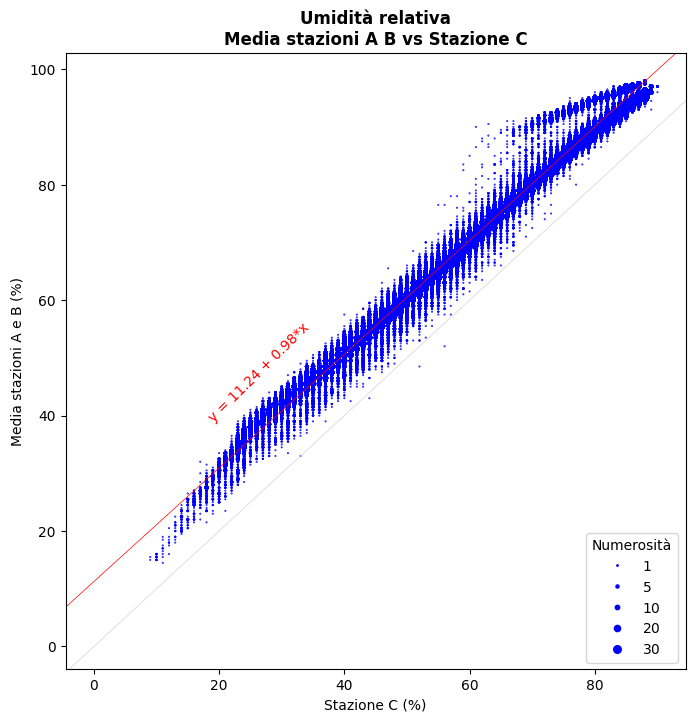

In [15]:
df_C = globals()["df_C_year_filt"][['Datetime','outHum']]
df_merged = pd.merge(df_C, df_avgAB, on='Datetime', suffixes=('_C', '_avgAB'))
#display(df_merged)
df_merged = df_merged.dropna()

# Regressione Lineare
model = LinearRegression()
model.fit(df_merged['outHum_C'].to_numpy().reshape((-1, 1)), df_merged['outHum_avgAB'].to_numpy()) #training data arpae
#reshape -1 lascia libero il numero di righe, qui diventa [[1.6],[0.2],...] (1 colonna)
#in X possono esserci più caratteristiche che corrispondono alla stessa y, es [ [1.6, 87], [0.2, 99] ]
interceptU = model.intercept_
slopeU = model.coef_[0]

# Definizione delle grandezze dei marker, in funzione della numerosità
c = Counter( zip(df_merged['outHum_C'], df_merged['outHum_avgAB']) ) #crea tuple di tuple: ( (arr[0], brr[0]), (arr[1], brr[1]) )
s = [0.2*c[(xx,yy)] for xx,yy in zip(df_merged['outHum_C'],df_merged['outHum_avgAB'])]

fig, ax = plt.subplots(figsize=(8,8))

# Linea diagonale, che rappresenta una relazione lineare tra le due stazioni
ax.axline((1, 1), slope=1, color='lightgrey',linewidth=0.5)
ax.axline((0, interceptU), slope=slopeU, color='red',linewidth=0.5) 

scatter_plot = plt.scatter(df_merged['outHum_C'], df_merged['outHum_avgAB'], s=s, color='blue', label='Numero di occorrenze')

plt.xlabel('Stazione C (%)')
plt.ylabel('Media stazioni A e B (%)')
#plt.xlim(-1,12)
#plt.ylim(-1,12)

ax.legend(*scatter_plot.legend_elements(prop="sizes", num=[1,5,10,20,30], color='blue'), loc=(0.84,0.01),title='Numerosità')

plt.text(18,39,f'y = {round(interceptU,2)} + {round(slopeU,2)}*x',rotation=np.rad2deg(math.atan(slopeU)),color='red')
plt.title('Umidità relativa\nMedia stazioni A B vs Stazione C', fontweight="bold")

plt.savefig('FIGURE/B/correction_ur_C_vs_AB.png', dpi=300, bbox_inches='tight')


<span style="font-size: large;">**6. Correzione lin temp e um rel C**

In [16]:
df_C = globals()["df_C_year_filt"]
#temp
df_C['outTemp_raw'] = df_C['outTemp']
df_C['outTemp'] = interceptT + df_C['outTemp_raw']*slopeT
#ur
df_C['outHum_raw'] = df_C['outHum']
df_C['outHum'] = interceptU + df_C['outHum_raw']*slopeU
globals()["df_C_year_filt"] = df_C

<span style="font-size: large;">**7. Confronto giornaliero su media stagionale A-B-C**

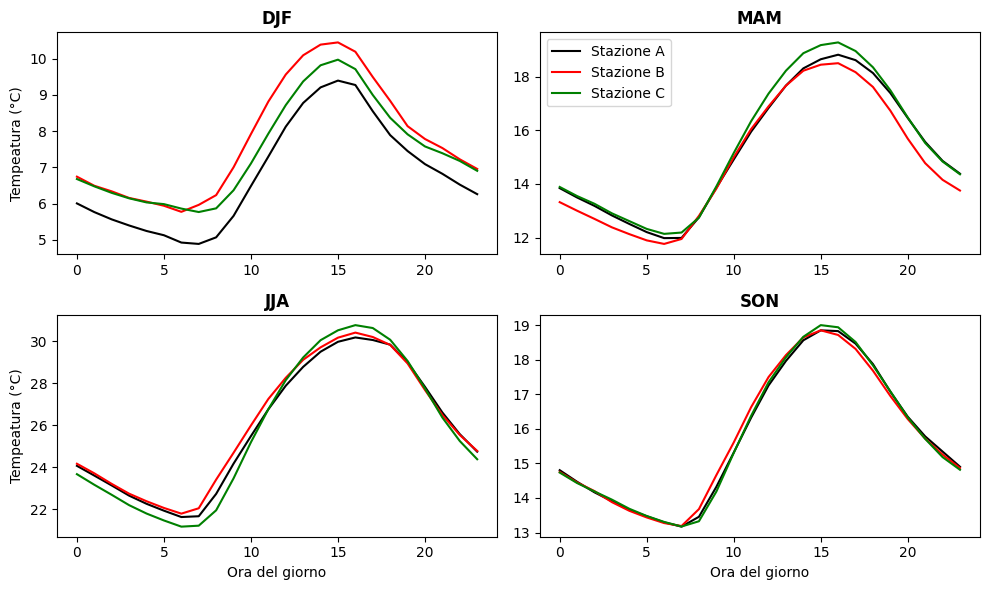

In [17]:
stagioni = ['DJF','MAM','JJA','SON']
colori = ['blue','green','orange','red']
A = globals()["df_A_year_filt"].copy()
B = globals()["df_B_year_filt"].copy()
C = globals()["df_C_year_filt"].copy()

fig_timeseries = plt.figure(figsize=(10, 6))
for i, stagione in enumerate(stagioni):

    plt.subplot(2, 2, i+1)
    tpA = A[A['Stagione']==stagione].groupby(A.Datetime.dt.hour)['outTemp'].mean()
    tpB = B[B['Stagione']==stagione].groupby(B.Datetime.dt.hour)['outTemp'].mean()
    tpC = C[C['Stagione']==stagione].groupby(C.Datetime.dt.hour)['outTemp'].mean()
    plt.plot(np.arange(0,24),tpA,color='black')
    plt.plot(np.arange(0,24),tpB,color='red')
    plt.plot(np.arange(0,24),tpC,color='green')
    #plt.ylim(0,1.75)
    #plt.xlim(0,23)
    plt.title(stagione,fontweight='bold')
    if i == 1:
        plt.legend(['Stazione A', 'Stazione B', 'Stazione C'], loc='upper left')
    if i+1 in [1,3]:
        plt.ylabel("Tempeatura (°C)")
    if i+1 in [3,4]:
        plt.xlabel("Ora del giorno")
    
    '''ax2 = plt.gca().twinx()
    ax2.spines['right'].set_color('red')
    ax2.tick_params(axis='y', colors='red')
    ax2.plot(np.arange(0,24),tpC,color='red')
#    ax2.set_ylim(0,30)
    if i+1 in [2,4]:
        ax2.set_ylabel('Temp C (°C)',rotation=-90,labelpad=12,color='red')'''

plt.tight_layout()
plt.savefig('FIGURE/B/tempVSore_confronto_tutti.png', dpi=300, bbox_inches='tight')

<span style="font-size: x-large;">**Confronto con ARPA**<span style="font-size: x-large;">  

<span style="font-size: large;">**1. medio davis su un ora**

In [18]:
for stazione in stazioni:
    df = globals()["df_"+stazione+"_year_filt"].copy()
    print(stazione)
    df['Datetime'] = df['Datetime'].dt.floor('H') #arrotondo ora precedente
    df = df.drop('Stagione', axis=1).groupby('Datetime').mean() #elimino stagione che non si può mediare
    df['Interval'] = 60
    display(df)
    globals()["df_"+stazione+"_year_1h"] = df

A


,Interval,Press,inTemp,outTemp,inHum,outHum,wndSpeed,wndDir,windGust,wGstDir,rainRate,rain,dewpoint,wdChill,heatIndx,ET,totRad,UV
Datetime,,,,,,,,,,,,,,,,,,
2015-01-02 14:00:00,60,1029.755,16.195,8.14,31.0,51.0,1.1175,303.75,3.3525,315.0,0.0,0.0,-1.39,8.14,8.14,0.065,209.0,1.25
2015-01-02 15:00:00,60,1029.345,16.305,8.305,31.0,54.0,0.894,303.75,2.4585,337.5,0.0,0.0,-0.455,8.305,8.305,0.05,145.0,1.0
2015-01-02 16:00:00,60,1028.775,16.36,7.86,31.5,58.0,0.447,281.25,1.788,270.0,0.0,0.0,0.115,7.86,7.86,0.025,44.5,0.3
2015-01-02 17:00:00,60,1028.67,16.47,7.475,32.0,58.0,0.447,270.0,2.0115,270.0,0.0,0.0,-0.25,7.475,7.475,0.015,2.0,0.0
2015-01-02 18:00:00,60,1028.7,16.56,7.165,32.0,61.5,0.447,270.0,2.0115,292.5,0.0,0.0,0.265,7.165,7.165,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 19:00:00,60,1030.04,20.22,5.22,29.0,74.0,0.447,315.0,1.788,315.0,0.0,0.0,0.97,5.22,5.22,0.03,0.0,0.0
2016-12-31 20:00:00,60,1029.77,20.11,4.305,30.0,77.0,0.2235,315.0,1.1175,315.0,0.0,0.0,0.63,4.305,4.305,0.015,0.0,0.0
2016-12-31 21:00:00,60,1029.485,20.11,3.805,30.0,77.5,0.2235,315.0,0.894,315.0,0.0,0.0,0.24,3.805,3.805,0.0,0.0,0.0


B


,Interval,Press,inTemp,outTemp,inHum,outHum,wndSpeed,wndDir,windGust,wGstDir,rainRate,rain,dewpoint,wdChill,heatIndx,ET,totRad,UV
Datetime,,,,,,,,,,,,,,,,,,
2015-01-01 05:00:00,60,1030.11,15.22,0.11,25.0,57.0,0.894,270.0,3.576,292.5,0.0,0.0,-7.39,0.11,0.11,0.0,0.0,1.0
2015-01-01 06:00:00,60,1029.94,15.17,0.665,25.0,60.5,0.6705,270.0,3.7995,281.25,0.0,0.0,-6.095,0.665,0.665,0.015,0.0,1.0
2015-01-01 07:00:00,60,1029.94,15.17,1.5,24.0,57.0,1.341,247.5,4.47,225.0,0.0,0.0,-6.09,1.5,1.5,0.03,0.0,1.0
2015-01-01 14:00:00,60,1030.08,16.28,9.0,22.0,38.0,0.447,337.5,3.129,337.5,0.0,0.0,-4.56,9.0,9.0,0.0,255.0,1.5
2015-01-02 01:00:00,60,1029.99,15.415,2.695,26.0,67.5,0.6705,258.75,2.9055,258.75,0.0,0.0,-2.71,2.695,2.695,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-28 21:00:00,60,1029.87,21.39,10.525,26.5,43.0,2.235,270.0,5.1405,258.75,0.0,0.0,-1.53,10.525,10.525,0.04,0.0,0.0
2016-12-31 20:00:00,60,1029.8,20.94,4.06,29.0,77.0,0.447,247.5,1.341,247.5,0.0,0.0,0.39,4.06,4.06,0.0,0.0,0.0
2016-12-31 21:00:00,60,1029.735,20.94,3.885,29.0,77.5,0.6705,270.0,1.341,270.0,0.0,0.0,0.32,3.885,3.885,0.015,0.0,0.0


C


,Interval,Press,inTemp,outTemp,inHum,outHum,wndSpeed,wndDir,windGust,wGstDir,rainRate,rain,dewpoint,wdChill,heatIndx,ET,totRad,UV,outTemp_raw,outHum_raw
Datetime,,,,,,,,,,,,,,,,,,,,
2015-01-02 12:00:00,60,1029.91,15.89,7.041727,32.0,51.617842,1.341,292.5,3.576,292.5,0.0,0.0,-8.36,3.67,3.67,0.0,320.0,1.9,3.67,41.0
2015-01-02 13:00:00,60,1028.825,16.0,7.545447,32.0,50.140599,0.894,315.0,3.3525,292.5,0.0,0.0,-8.385,4.17,4.17,0.065,247.5,1.9,4.17,39.5
2015-01-02 14:00:00,60,1027.875,16.14,7.877902,32.0,49.648185,0.6705,315.0,2.9055,337.5,0.0,0.0,-8.25,4.5,4.5,0.05,201.5,1.7,4.5,39.0
2015-01-02 15:00:00,60,1027.465,16.25,8.099539,32.0,52.602671,0.6705,315.0,2.235,303.75,0.0,0.0,-7.095,4.72,4.72,0.05,121.5,1.45,4.72,42.0
2015-01-02 16:00:00,60,1027.045,16.33,7.595819,32.0,55.557157,0.0,315.0,1.341,168.75,0.0,0.0,-6.65,4.22,4.22,0.025,38.0,1.25,4.22,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 19:00:00,60,1028.4,20.11,4.633947,30.0,73.284074,0.0,-99.9,0.0,-99.9,0.0,0.0,-4.985,1.28,1.28,0.0,0.0,0.9,1.28,63.0
2016-12-31 20:00:00,60,1028.11,20.11,4.06978,30.0,75.253732,0.0,-99.9,0.0,-99.9,0.0,0.0,-5.1,0.72,0.72,0.0,0.0,0.9,0.72,65.0
2016-12-31 21:00:00,60,1027.79,20.11,3.485466,30.0,76.238561,0.0,-99.9,0.0,-99.9,0.0,0.0,-5.45,0.14,0.14,0.0,0.0,0.9,0.14,66.0


Stesso nome a tp ur press in tabelle davis

In [19]:
for stazione in stazioni:
    print(stazione)
    df = globals()["df_"+stazione+"_year_1h"]
    df.rename(columns={"outTemp": "tpavg", "outHum": "uravg", "Press": "pressure"}, inplace=True)

A
B
C


<span style="font-size: large;">**2. CONFRONTO DAVIS ARAPE**

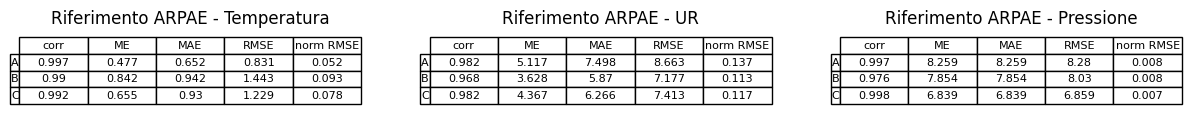

In [20]:
stazioni = ['A', 'B', 'C']
vars = ['tpavg', 'uravg', 'pressure']
name = [' - Temperatura', ' - UR', ' - Pressione']
fig, axes = plt.subplots(1, 3, figsize=(3 * 5, 1))
i = 0
for var in vars:
    rows = []
    for stazione in stazioni:
        corr, me, mae, rmse, nrmse = compare_column(globals()["df_ARPAE"], globals()["df_"+stazione+"_year_1h"], var)
        rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

    df = pd.DataFrame(rows, index=stazioni, columns=['corr', 'ME', 'MAE', 'RMSE', 'norm RMSE'])
    
    #table image from dataframe
    ax = axes[i]
    i +=1
    ax.axis('off')
    ax.set_title("Riferimento ARPAE"+name[vars.index(var)], loc='center')
    table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1)
    
plt.savefig('FIGURE/tp_ur_pr_compare_arpae.png', dpi=300, bbox_inches='tight')

<span style="font-size: x-large;">**Elimino dati B prima del 24/06/2015**<span style="font-size: x-large;">

In [26]:
#rename AC
globals()["df_A_year_filt_new"] = globals()["df_A_year_filt"].copy()
globals()["df_C_year_filt_new"] = globals()["df_C_year_filt"].copy()
#filtro B
df = globals()["df_B_year_filt"]
globals()["df_B_year_filt_new"] = df[df.Datetime > "24-06-2015"]
print(globals()["df_B_year_filt_new"].Datetime.min())

#reset correzione C
df_C = globals()["df_C_year_filt_new"]
df_C['outTemp'] = df_C['outTemp_raw']
df_C['outHum'] = df_C['outHum_raw']

2015-06-24 10:00:00


<span style="font-size: large;">**1. CORRELAZIONI**

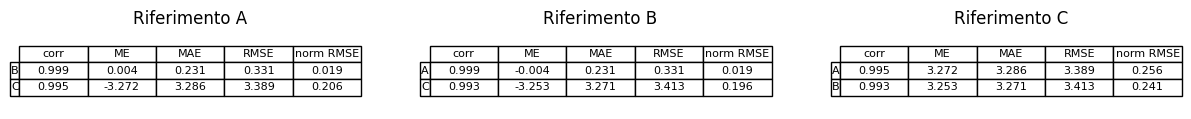

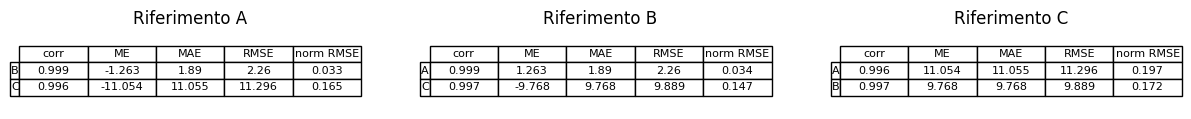

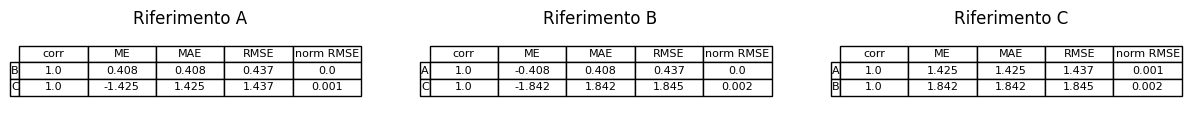

In [27]:
def statistics(var,ref):
    
    CORR = var.corrwith(ref)[0]
    ME = np.mean(np.subtract(var, ref))
    MAE = np.mean(np.abs(np.subtract(var, ref)))
    RMSE = np.sqrt(np.nanmean(np.square(np.subtract(var, ref))))
    nRMSE = RMSE / np.nanmean(ref)
    
    return CORR, ME, MAE, RMSE, nRMSE

def compare_column(ref, var, column_name):
    df = ref.copy()
    df_comp = var.copy()

    #seleziono dove stessa data
    common_index = list((df.index).intersection(df_comp.index))

    df_ref = df.loc[common_index].copy()
    df_to_comp = df_comp.loc[common_index].copy()
    corr,me,mae,rmse,nrmse = statistics(df_to_comp[[column_name]],df_ref[[column_name]])
    return corr,me,mae,rmse,nrmse

stazioni = ['A', 'B', 'C']
vars = ['outTemp', 'outHum', 'Press']
for var in vars:
    fig, axes = plt.subplots(1, 3, figsize=(3 * 5, 1))
    i = 0
    for riferimento in stazioni:
        rows = []
        #print("Riferimento "+riferimento)
        indexes = []
        for stazione in stazioni:
            if stazione != riferimento:
                indexes.append(stazione)
                corr, me, mae, rmse, nrmse = compare_column(globals()["df_"+riferimento+"_year_filt_new"], globals()["df_"+stazione+"_year_filt_new"], var)
                rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

        df = pd.DataFrame(rows, index=indexes, columns=['corr', 'ME', 'MAE', 'RMSE', 'norm RMSE'])
        #display(df)

        ax = axes[i]
        i +=1
        ax.axis('off')
        ax.set_title("Riferimento "+riferimento, loc='center')
        table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1)
    #plt.savefig('FIGURE/'+var+'_compare_davis.png', dpi=300, bbox_inches='tight')


<span style="font-size: large;">**2. REGRESSIONE LINEARE temp C - media(A,B)**

In [23]:
df_A = globals()["df_A_year_filt_new"][['Datetime','outTemp','outHum']].copy()
df_B = globals()["df_B_year_filt_new"][['Datetime','outTemp','outHum']].copy()
df_avgAB = pd.merge(df_A, df_B, on='Datetime', suffixes=('_A', '_B'))
df_avgAB['outTemp'] = (df_avgAB['outTemp_A'] + df_avgAB['outTemp_B'])/2
df_avgAB['outHum'] = (df_avgAB['outHum_A'] + df_avgAB['outHum_B'])/2

def get_season(month):
    if 3 <= month <= 5:
        return 'MAM'
    elif 6 <= month <= 8:
        return 'JJA'
    elif 9 <= month <= 11:
        return 'SON'
    else:
        return 'DJF'

#aggiungo indice di stagione
df_avgAB['Stagione'] = df_avgAB['Datetime'].dt.month.apply(get_season)
df_avgAB

,Datetime,outTemp_A,outHum_A,outTemp_B,outHum_B,outTemp,outHum,Stagione
0,2015-06-24 10:00:00,18.22,72.0,20.11,62.0,19.165,67.0,JJA
1,2015-06-24 11:30:00,20.17,64.0,21.44,57.0,20.805,60.5,JJA
2,2015-06-24 12:00:00,20.06,63.0,22.06,52.0,21.06,57.5,JJA
3,2015-06-24 13:30:00,22.56,55.0,22.56,52.0,22.56,53.5,JJA
4,2015-06-24 14:00:00,22.94,54.0,23.39,47.0,23.165,50.5,JJA
...,...,...,...,...,...,...,...,...
24670,2016-12-31 21:30:00,3.72,77.0,3.83,77.0,3.775,77.0,DJF
24671,2016-12-31 22:00:00,3.61,77.0,3.67,76.0,3.64,76.5,DJF
24672,2016-12-31 22:30:00,3.39,77.0,3.5,76.0,3.445,76.5,DJF
24673,2016-12-31 23:00:00,3.28,76.0,3.28,75.0,3.28,75.5,DJF


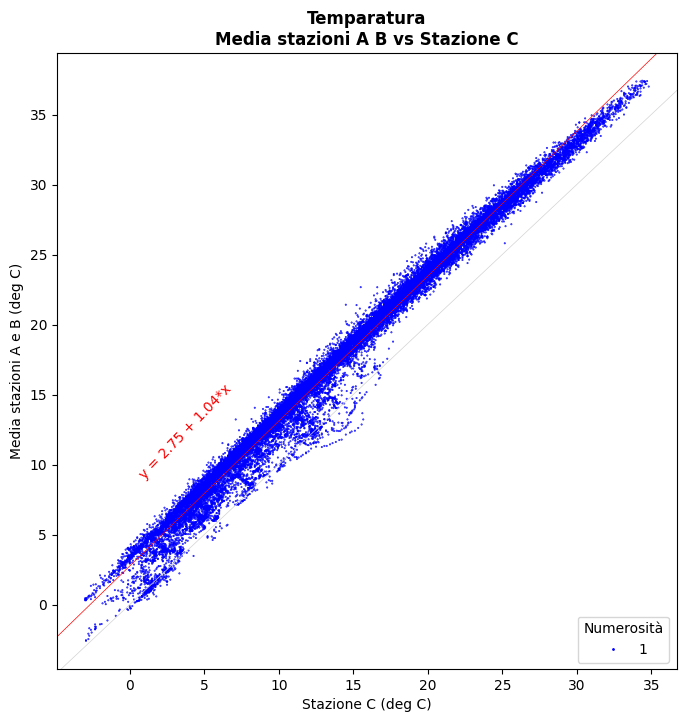

In [24]:
df_C = globals()["df_C_year_filt_new"][['Datetime','outTemp']]
df_merged = pd.merge(df_C, df_avgAB, on='Datetime', suffixes=('_C', '_avgAB'))
#display(df_merged)
df_merged = df_merged.dropna()

# Regressione Lineare
model = LinearRegression()
model.fit(df_merged['outTemp_C'].to_numpy().reshape((-1, 1)), df_merged['outTemp_avgAB'].to_numpy()) #training data arpae
#reshape -1 lascia libero il numero di righe, qui diventa [[1.6],[0.2],...] (1 colonna)
#in X possono esserci più caratteristiche che corrispondono alla stessa y, es [ [1.6, 87], [0.2, 99] ]
interceptT = model.intercept_
slopeT = model.coef_[0]

# Definizione delle grandezze dei marker, in funzione della numerosità
c = Counter( zip(df_merged['outTemp_C'], df_merged['outTemp_avgAB']) ) #crea tuple di tuple: ( (arr[0], brr[0]), (arr[1], brr[1]) )
s = [0.2*c[(xx,yy)] for xx,yy in zip(df_merged['outTemp_C'],df_merged['outTemp_avgAB'])]

fig, ax = plt.subplots(figsize=(8,8))

# Linea diagonale, che rappresenta una relazione lineare tra le due stazioni
ax.axline((1, 1), slope=1, color='lightgrey',linewidth=0.5)
ax.axline((0, interceptT), slope=slopeT, color='red',linewidth=0.5) 

scatter_plot = plt.scatter(df_merged['outTemp_C'], df_merged['outTemp_avgAB'], s=s, color='blue', label='Numero di occorrenze')

plt.xlabel('Stazione C (deg C)')
plt.ylabel('Media stazioni A e B (deg C)')
#plt.xlim(-1,12)
#plt.ylim(-1,12)

ax.legend(*scatter_plot.legend_elements(prop="sizes", num=[1,2,5,10,20], color='blue'), loc=(0.84,0.01),title='Numerosità')

plt.text(0.5,9,f'y = {round(interceptT,2)} + {round(slopeT,2)}*x',rotation=np.rad2deg(math.atan(slopeT)),color='red')
plt.title('Temparatura\nMedia stazioni A B vs Stazione C', fontweight="bold")

plt.savefig('FIGURE/C/correction_tp_C_vs_AB_noOld.png', dpi=300, bbox_inches='tight')


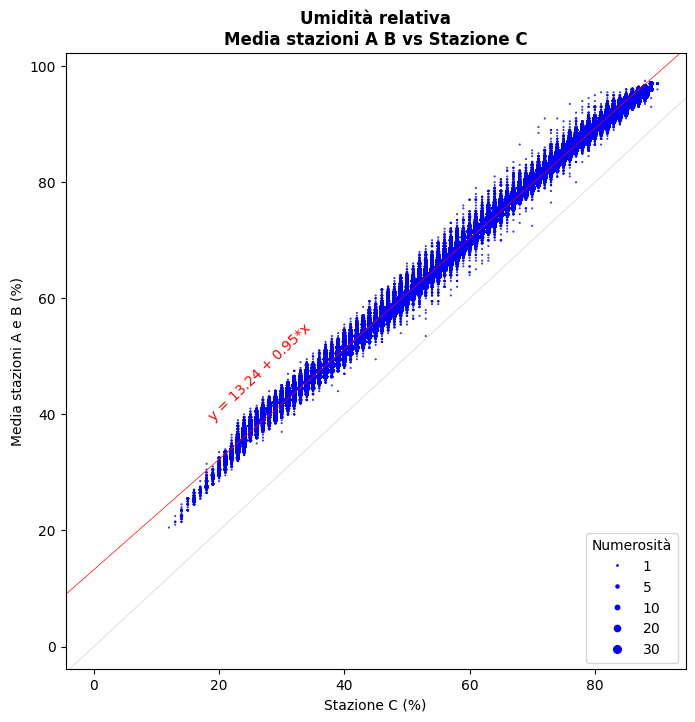

In [28]:
df_C = globals()["df_C_year_filt_new"][['Datetime','outHum']]
df_merged = pd.merge(df_C, df_avgAB, on='Datetime', suffixes=('_C', '_avgAB'))
#display(df_merged)
df_merged = df_merged.dropna()

# Regressione Lineare
model = LinearRegression()
model.fit(df_merged['outHum_C'].to_numpy().reshape((-1, 1)), df_merged['outHum_avgAB'].to_numpy()) #training data arpae
#reshape -1 lascia libero il numero di righe, qui diventa [[1.6],[0.2],...] (1 colonna)
#in X possono esserci più caratteristiche che corrispondono alla stessa y, es [ [1.6, 87], [0.2, 99] ]
interceptU = model.intercept_
slopeU = model.coef_[0]

# Definizione delle grandezze dei marker, in funzione della numerosità
c = Counter( zip(df_merged['outHum_C'], df_merged['outHum_avgAB']) ) #crea tuple di tuple: ( (arr[0], brr[0]), (arr[1], brr[1]) )
s = [0.2*c[(xx,yy)] for xx,yy in zip(df_merged['outHum_C'],df_merged['outHum_avgAB'])]

fig, ax = plt.subplots(figsize=(8,8))

# Linea diagonale, che rappresenta una relazione lineare tra le due stazioni
ax.axline((1, 1), slope=1, color='lightgrey',linewidth=0.5)
ax.axline((0, interceptU), slope=slopeU, color='red',linewidth=0.5) 

scatter_plot = plt.scatter(df_merged['outHum_C'], df_merged['outHum_avgAB'], s=s, color='blue', label='Numero di occorrenze')

plt.xlabel('Stazione C (%)')
plt.ylabel('Media stazioni A e B (%)')
#plt.xlim(-1,12)
#plt.ylim(-1,12)

ax.legend(*scatter_plot.legend_elements(prop="sizes", num=[1,5,10,20,30], color='blue'), loc=(0.84,0.01),title='Numerosità')

plt.text(18,39,f'y = {round(interceptU,2)} + {round(slopeU,2)}*x',rotation=np.rad2deg(math.atan(slopeU)),color='red')
plt.title('Umidità relativa\nMedia stazioni A B vs Stazione C', fontweight="bold")

plt.savefig('FIGURE/C/correction_ur_C_vs_AB_noOld.png', dpi=300, bbox_inches='tight')


<span style="font-size: large;">**3. CORREZIONE LINEARE C**

In [29]:
df_C = globals()["df_C_year_filt_new"]
df_C['outTemp_raw'] = df_C['outTemp']
df_C['outTemp'] = interceptT + df_C['outTemp_raw']*slopeT
df_C['outHum_raw'] = df_C['outHum']
df_C['outHum'] = interceptU + df_C['outHum_raw']*slopeU
globals()["df_C_year_filt_new"] = df_C

<span style="font-size: large;">**4. Confronto giornaliero su media stagionale A-B-C**

[[9.397482993197286, 9.420225988700569, 9.568505767507265], [18.820326086956523, 18.560546448087432, 19.12772294685818], [30.188429752066103, 30.419184952978053, 30.940995396505276], [18.8465536723164, 18.846874999999997, 18.83832422926223]]
[[3.3880416773646114, 3.5622062805237102, 3.1500930361763078], [5.286490819010386, 5.190468835540854, 5.544916331621498], [4.0101897851779436, 4.107462294826415, 4.354006037285007], [6.664185108473552, 6.613906561716949, 6.750319564614762]]


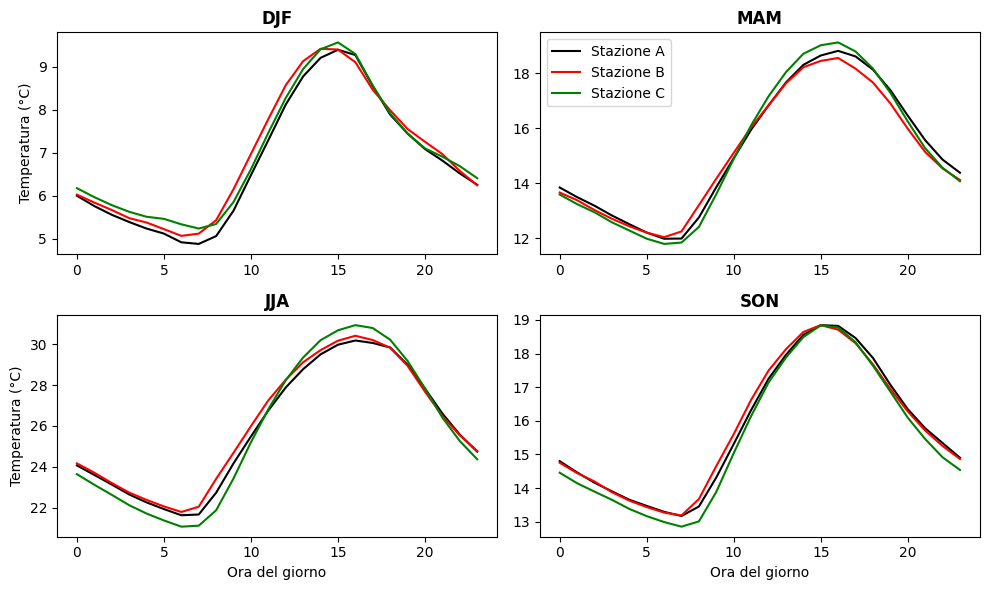

In [80]:
stagioni = ['DJF','MAM','JJA','SON']
colori = ['blue','green','orange','red']
A = globals()["df_A_year_filt_new"].copy()
B = globals()["df_B_year_filt_new"].copy()
C = globals()["df_C_year_filt_new"].copy()
max = [] #index per le stagioni[a,b,c]
max_std = []

fig_timeseries = plt.figure(figsize=(10, 6))
for i, stagione in enumerate(stagioni):

    plt.subplot(2, 2, i+1)
    tpA = A[A['Stagione']==stagione].groupby(A.Datetime.dt.hour)['outTemp'].mean()
    tpB = B[B['Stagione']==stagione].groupby(B.Datetime.dt.hour)['outTemp'].mean()
    tpC = C[C['Stagione']==stagione].groupby(C.Datetime.dt.hour)['outTemp'].mean()
    #calcolo massimi delle curve
    max.append([tpA.max(), tpB.max(), tpC.max()])
    #calcolo dev del massimo
    ora_max_A = tpA.index[tpA == tpA.max()][0]
    ora_max_B = tpB.index[tpB == tpB.max()][0]
    ora_max_C = tpC.index[tpC == tpC.max()][0]
    tpAstd = A[ (A['Stagione']==stagione) & (A.Datetime.dt.floor('H').dt.hour == ora_max_A) ] ['outTemp'].std()
    tpBstd = B[ (B['Stagione']==stagione) & (B.Datetime.dt.floor('H').dt.hour == ora_max_B) ] ['outTemp'].std()
    tpCstd = C[ (C['Stagione']==stagione) & (C.Datetime.dt.floor('H').dt.hour == ora_max_C) ] ['outTemp'].std()
    max_std.append([tpAstd.item(), tpBstd.item(), tpCstd.item()]) #from float numpy to python

    plt.plot(tpA.index,tpA,color='black')
    plt.plot(tpB.index,tpB,color='red')
    plt.plot(tpC.index,tpC,color='green')
    #plt.ylim(0,1.75)
    #plt.xlim(0,23)
    plt.title(stagione,fontweight='bold')
    if i == 1:
        plt.legend(['Stazione A', 'Stazione B', 'Stazione C'], loc='upper left')
    if i+1 in [1,3]:
        plt.ylabel("Temperatura (°C)")
    if i+1 in [3,4]:
        plt.xlabel("Ora del giorno")
    
    '''ax2 = plt.gca().twinx()
    ax2.spines['right'].set_color('red')
    ax2.tick_params(axis='y', colors='red')
    ax2.plot(np.arange(0,24),tpC,color='red')
#    ax2.set_ylim(0,30)
    if i+1 in [2,4]:
        ax2.set_ylabel('Temp C (°C)',rotation=-90,labelpad=12,color='red')'''

plt.tight_layout()
plt.savefig('FIGURE/C/tempVSore_confronto_noOld.png', dpi=300, bbox_inches='tight')
print(max)
print(max_std)
#DOMANDA, vince errore elevato per dire no oppure vedere su due anni di media un andamento si sovrastima e sottostima per dire si

<span style="font-size: large;">**7. Confronto media oraria stagionale A-C, con vento**

In [36]:
dfA = df_A_year_filt_new[['Datetime','wndSpeed','wndDir','outTemp']].copy()
dfC = df_C_year_filt_new[['Datetime','wndSpeed','wndDir','outTemp']].copy()
dfB = df_B_year_filt_new[['Datetime','wndSpeed','wndDir','outTemp']].copy()
dfC_w = dfC[(dfC['wndSpeed'] >= 2)&(dfC['wndSpeed']<=8)&(dfC['wndDir'] >= 0)&(dfC['wndDir']<360)]
df_mergeAC = pd.merge(dfC_w, dfA, on='Datetime', suffixes=('_C', '_A'))

df_merge = pd.merge(df_mergeAC, dfB, on='Datetime', suffixes=('', '_B'))
#aggiungo indice di stagione
df_merge['Stagione'] = df_merge['Datetime'].dt.month.apply(get_season)
df_merge

,Datetime,wndSpeed_C,wndDir_C,outTemp_C,wndSpeed_A,wndDir_A,outTemp_A,wndSpeed,wndDir,outTemp,Stagione
0,2015-06-27 18:30:00,2.235,202.5,30.248614,3.129,202.5,29.67,3.576,180.0,28.89,JJA
1,2015-06-27 22:30:00,2.682,135.0,23.633886,3.576,112.5,23.67,4.47,112.5,20.61,JJA
2,2015-06-28 19:00:00,2.682,135.0,29.151335,3.129,90.0,29.0,3.576,112.5,28.67,JJA
3,2015-06-28 19:30:00,2.235,135.0,28.519882,3.129,90.0,28.56,4.023,112.5,28.22,JJA
4,2015-07-07 23:00:00,2.682,202.5,31.966994,3.129,202.5,32.11,3.576,202.5,31.83,JJA
...,...,...,...,...,...,...,...,...,...,...,...
940,2016-12-27 12:30:00,2.235,292.5,11.843314,2.235,292.5,12.72,3.129,292.5,12.78,DJF
941,2016-12-27 13:00:00,2.235,315.0,12.184919,2.235,292.5,12.94,3.129,292.5,13.06,DJF
942,2016-12-27 13:30:00,2.235,315.0,12.526525,1.788,292.5,13.39,2.682,292.5,13.67,DJF
943,2016-12-27 14:00:00,2.235,315.0,13.16833,1.788,315.0,14.0,2.235,315.0,14.17,DJF


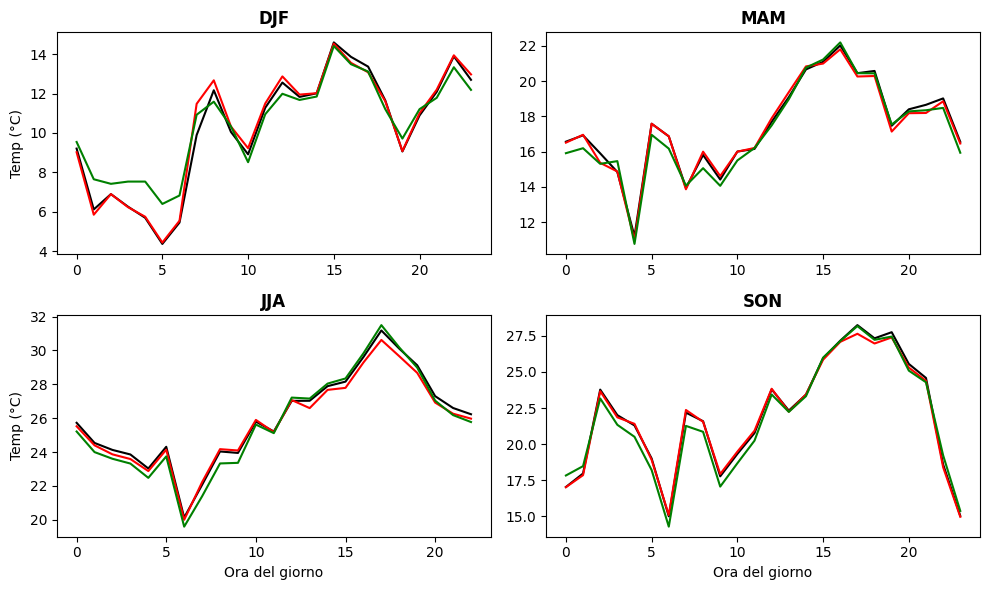

In [38]:
stagioni = ['DJF','MAM','JJA','SON']
colori = ['blue','green','orange','red']

fig_timeseries = plt.figure(figsize=(10, 6))

for i, stagione in enumerate(stagioni):

    plt.subplot(2, 2, i+1)
    tpA = df_merge[df_merge['Stagione']==stagione].groupby(df_merge.Datetime.dt.hour)['outTemp_A'].mean()
    tpB = df_merge[df_merge['Stagione']==stagione].groupby(df_merge.Datetime.dt.hour)['outTemp'].mean()
    tpC = df_merge[df_merge['Stagione']==stagione].groupby(df_merge.Datetime.dt.hour)['outTemp_C'].mean()
    plt.plot(np.arange(0,len(tpA)),tpA,color='black')
    plt.plot(np.arange(0,len(tpB)),tpB,color='red')
    plt.plot(np.arange(0,len(tpC)),tpC,color='green')
    #plt.ylim(0,1.75)
    #plt.xlim(0,23)
    plt.title(stagione,fontweight='bold')
    if i+1 in [1,3]:
        plt.ylabel("Temp (°C)")
    if i+1 in [3,4]:
        plt.xlabel("Ora del giorno")
    
    '''ax2 = plt.gca().twinx()
    ax2.spines['right'].set_color('red')
    ax2.tick_params(axis='y', colors='red')
    ax2.plot(np.arange(0,24),tpC,color='red')
#    ax2.set_ylim(0,30)
    if i+1 in [2,4]:
        ax2.set_ylabel('Temp C (°C)',rotation=-90,labelpad=12,color='red')'''

plt.tight_layout()
#plt.savefig('FIGURE/C/tempVSore_confronto_tutti.png', dpi=300, bbox_inches='tight')

CONFRONTO TP - WIND

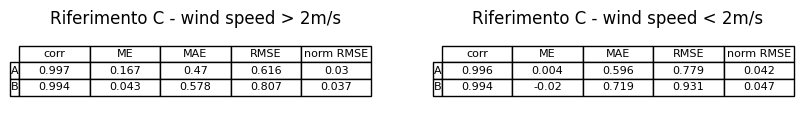

In [40]:
var = 'outTemp'

dfC = df_C_year_filt_new[['Datetime','wndSpeed','wndDir','outTemp']].copy()
dfC_w = dfC[(dfC['wndSpeed'] >= 2)&(dfC['wndSpeed']<=8)&(dfC['wndDir'] >= 0)&(dfC['wndDir']<360)]

fig, axes = plt.subplots(1, 2, figsize=(5*2, 1))
rows = []
#print("Riferimento "+riferimento)
indexes = ['A','B']
for stazione in ['A','B']:
    corr, me, mae, rmse, nrmse = compare_column(dfC_w, globals()["df_"+stazione+"_year_filt_new"], var)
    rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

df = pd.DataFrame(rows, index=indexes, columns=['corr', 'ME', 'MAE', 'RMSE', 'norm RMSE'])
#display(df)

ax = axes[0]
ax.axis('off')
ax.set_title("Riferimento C - wind speed > 2m/s", loc='center')
table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)

##################################### wind < 2m/s
dfC_w = dfC[(dfC['wndSpeed'] >= 0.5)&(dfC['wndSpeed'] < 2)&(dfC['wndDir'] >= 0)&(dfC['wndDir']<360)]
rows = []
#print("Riferimento "+riferimento)
indexes = ['A','B']
for stazione in ['A','B']:
    corr, me, mae, rmse, nrmse = compare_column(dfC_w, globals()["df_"+stazione+"_year_filt_new"], var)
    rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

df = pd.DataFrame(rows, index=indexes, columns=['corr', 'ME', 'MAE', 'RMSE', 'norm RMSE'])
#display(df)

ax = axes[1]
ax.axis('off')
ax.set_title("Riferimento C - wind speed < 2m/s", loc='center')
table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)
#plt.savefig('FIGURE/'+var+'_compare_davis.png', dpi=300, bbox_inches='tight')


CONFRONTO TP ore centrali - WIND

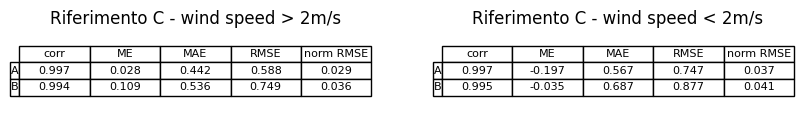

In [42]:
var = 'outTemp'

dfC = df_C_year_filt_new[['Datetime','wndSpeed','wndDir','outTemp']].copy()
dfC_w = dfC[(dfC['wndSpeed'] >= 2)&(dfC['wndSpeed']<=8)&(dfC['wndDir'] >= 0)&(dfC['wndDir']<360) &
            (dfC.Datetime.dt.hour > 10) & (dfC.Datetime.dt.hour < 16) ] #ore 13 -3 e +3

fig, axes = plt.subplots(1, 2, figsize=(5*2, 1))
rows = []
#print("Riferimento "+riferimento)
indexes = ['A','B']
for stazione in ['A','B']:
    corr, me, mae, rmse, nrmse = compare_column(dfC_w, globals()["df_"+stazione+"_year_filt_new"], var)
    rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

df = pd.DataFrame(rows, index=indexes, columns=['corr', 'ME', 'MAE', 'RMSE', 'norm RMSE'])
#display(df)

ax = axes[0]
ax.axis('off')
ax.set_title("Riferimento C - wind speed > 2m/s", loc='center')
table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)

##################################### wind < 2m/s
dfC_w = dfC[(dfC['wndSpeed'] >= 0.5)&(dfC['wndSpeed'] < 2)&(dfC['wndDir'] >= 0)&(dfC['wndDir']<360)
             &
            (dfC.Datetime.dt.hour > 10) & (dfC.Datetime.dt.hour < 16) ]
rows = []
#print("Riferimento "+riferimento)
indexes = ['A','B']
for stazione in ['A','B']:
    corr, me, mae, rmse, nrmse = compare_column(dfC_w, globals()["df_"+stazione+"_year_filt_new"], var)
    rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

df = pd.DataFrame(rows, index=indexes, columns=['corr', 'ME', 'MAE', 'RMSE', 'norm RMSE'])
#display(df)

ax = axes[1]
ax.axis('off')
ax.set_title("Riferimento C - wind speed < 2m/s", loc='center')
table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)
#plt.savefig('FIGURE/'+var+'_compare_davis.png', dpi=300, bbox_inches='tight')


DAILY MAX E WIND

51
274


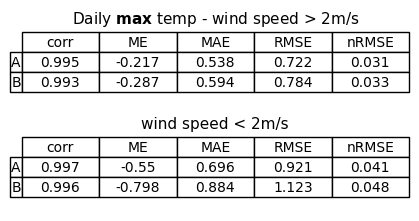

In [72]:
dfC = df_C_year_filt_new[['Datetime','wndSpeed','wndDir','outTemp']].copy()

maxGG_C = dfC.groupby(dfC.Datetime.dt.floor('d'))['outTemp'].max()
dfC_MAX = pd.DataFrame()
for date in maxGG_C.index:
    dfC_MAX = pd.concat([dfC_MAX, pd.DataFrame(dfC[(dfC.Datetime.dt.floor('d') == date) & (dfC.outTemp == maxGG_C[date]) &
                                                   (dfC.wndSpeed >= 2) & (dfC.wndSpeed <= 8) &
                                                   (dfC.wndDir >= 0)&(dfC.wndDir < 360) ])])
print(dfC_MAX.shape[0])

fig, axes = plt.subplots(2, 1, figsize=(5, 2.5))
rows = []
#print("Riferimento "+riferimento)
indexes = ['A','B']
for stazione in ['A','B']:
    corr, me, mae, rmse, nrmse = compare_column(dfC_MAX, globals()["df_"+stazione+"_year_filt_new"], var)
    rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

df = pd.DataFrame(rows, index=indexes, columns=['corr', 'ME', 'MAE', 'RMSE', 'nRMSE'])
#display(df)

ax = axes[0]
ax.axis('off')
ax.set_title("Daily "+r"$\bf{max}$ temp - wind speed > 2m/s", loc='center', y=0.85, fontsize=11)
table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.2)

##################################### wind < 2m/s
dfC_MAX = pd.DataFrame()
for date in maxGG_C.index:
    dfC_MAX = pd.concat([dfC_MAX, pd.DataFrame(dfC[(dfC.Datetime.dt.floor('d') == date) & (dfC.outTemp == maxGG_C[date]) &
                                                   (dfC.wndSpeed >= 0.5) & (dfC.wndSpeed < 2) &
                                                   (dfC.wndDir >= 0)&(dfC.wndDir < 360) ])])
print(dfC_MAX.shape[0])

rows = []
#print("Riferimento "+riferimento)
indexes = ['A','B']
for stazione in ['A','B']:
    corr, me, mae, rmse, nrmse = compare_column(dfC_MAX, globals()["df_"+stazione+"_year_filt_new"], var)
    rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

df = pd.DataFrame(rows, index=indexes, columns=['corr', 'ME', 'MAE', 'RMSE', 'nRMSE'])
#display(df)

ax = axes[1]
ax.axis('off')
ax.set_title("wind speed < 2m/s", loc='center', y=0.85, fontsize=11)
table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.2)
plt.savefig('FIGURE/C/max_wind_shield.png', dpi=300, bbox_inches='tight')

MIN DAILY - WIND

11
164


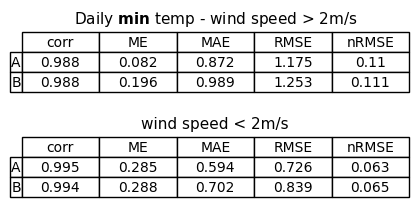

In [73]:
dfC = df_C_year_filt_new[['Datetime','wndSpeed','wndDir','outTemp']].copy()

minGG_C = dfC.groupby(dfC.Datetime.dt.floor('d'))['outTemp'].min()
dfC_MIN = pd.DataFrame()
for date in minGG_C.index:
    dfC_MIN = pd.concat([dfC_MIN, pd.DataFrame(dfC[(dfC.Datetime.dt.floor('d') == date) & (dfC.outTemp == minGG_C[date]) &
                                                   (dfC.wndSpeed >= 2) & (dfC.wndSpeed <= 8) &
                                                   (dfC.wndDir >= 0)&(dfC.wndDir < 360) ])])
print(dfC_MIN.shape[0])

fig, axes = plt.subplots(2, 1, figsize=(5, 2.5))
rows = []
#print("Riferimento "+riferimento)
indexes = ['A','B']
for stazione in ['A','B']:
    corr, me, mae, rmse, nrmse = compare_column(dfC_MIN, globals()["df_"+stazione+"_year_filt_new"], var)
    rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

df = pd.DataFrame(rows, index=indexes, columns=['corr', 'ME', 'MAE', 'RMSE', 'nRMSE'])
#display(df)

ax = axes[0]
ax.axis('off')
ax.set_title("Daily "+r"$\bf{min}$ temp - wind speed > 2m/s", loc='center', y=0.85, fontsize=11)
table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.2)

##################################### wind < 2m/s
dfC_MIN = pd.DataFrame()
for date in minGG_C.index:
    dfC_MIN = pd.concat([dfC_MIN, pd.DataFrame(dfC[(dfC.Datetime.dt.floor('d') == date) & (dfC.outTemp == minGG_C[date]) &
                                                   (dfC.wndSpeed >= 0.5) & (dfC.wndSpeed < 2) &
                                                   (dfC.wndDir >= 0)&(dfC.wndDir < 360) ])])
print(dfC_MIN.shape[0])

rows = []
#print("Riferimento "+riferimento)
indexes = ['A','B']
for stazione in ['A','B']:
    corr, me, mae, rmse, nrmse = compare_column(dfC_MIN, globals()["df_"+stazione+"_year_filt_new"], var)
    rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

df = pd.DataFrame(rows, index=indexes, columns=['corr', 'ME', 'MAE', 'RMSE', 'nRMSE'])
#display(df)

ax = axes[1]
ax.axis('off')
ax.set_title("wind speed < 2m/s", loc='center', y=0.85, fontsize=11)
table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.2)
plt.savefig('FIGURE/C/min_wind_shield.png', dpi=300, bbox_inches='tight')

7
38
22
95
11
87
11
54


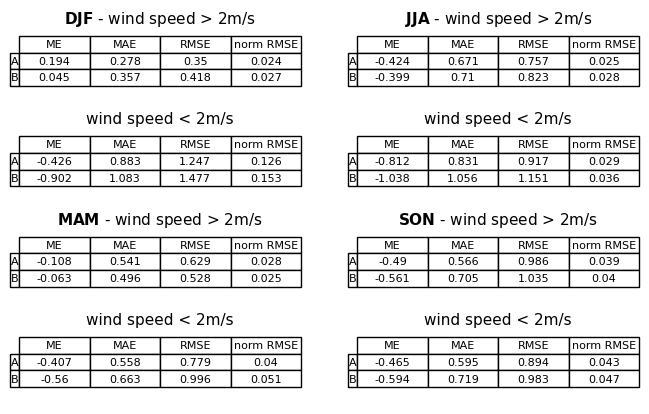

In [74]:
var = 'outTemp'
stagioni = ['DJF', 'MAM', 'JJA', 'SON']
dfC = df_C_year_filt_new[['Datetime','wndSpeed','wndDir','outTemp','Stagione']].copy()

fig, axes = plt.subplots(4, 2, figsize=(2*5 -2, 2*2.5))
#axes = axes_p.flatten() #così accedo con un indice solo alla 2x2
sss = 0
for col in range(2):  # 2 colonne
    for row in range(0, 4, 2):  # 4 righe, ma passo di 2 (0, 2)
        stagione = stagioni[sss]
        maxGG_C = dfC.groupby(dfC.Datetime.dt.floor('d'))['outTemp'].max()
        dfC_MAX = pd.DataFrame()
        for date in maxGG_C.index:
            dfC_MAX = pd.concat([dfC_MAX, pd.DataFrame(dfC[(dfC.Datetime.dt.floor('d') == date) & (dfC.outTemp == maxGG_C[date]) &
                                                        (dfC.wndSpeed >= 2) & (dfC.wndSpeed <= 8) &
                                                        (dfC.wndDir >= 0)&(dfC.wndDir < 360) &
                                                        (dfC.Stagione == stagione)])])
        print(dfC_MAX.shape[0])

        rows = []
        #print("Riferimento "+riferimento)
        indexes = ['A','B']
        for stazione in ['A','B']:
            corr, me, mae, rmse, nrmse = compare_column(dfC_MAX, globals()["df_"+stazione+"_year_filt_new"], var)
            rows.append([round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

        df = pd.DataFrame(rows, index=indexes, columns=['ME', 'MAE', 'RMSE', 'norm RMSE'])
        #display(df)

        ax = axes[row, col]  # primo axes del blocco
        ax.axis('off')
        ax.set_title(r"$\bf{"+ stagione + "}$ - wind speed > 2m/s", loc='center', y=0.85, fontsize=11)
        table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1)

        ##################################### wind < 2m/s
        dfC_MAX = pd.DataFrame()
        for date in maxGG_C.index:
            dfC_MAX = pd.concat([dfC_MAX, pd.DataFrame(dfC[(dfC.Datetime.dt.floor('d') == date) & (dfC.outTemp == maxGG_C[date]) &
                                                        (dfC.wndSpeed >= 0.5) & (dfC.wndSpeed < 2) &
                                                        (dfC.wndDir >= 0)&(dfC.wndDir < 360) &
                                                        (dfC.Stagione == stagione)])])
        print(dfC_MAX.shape[0])

        rows = []
        #print("Riferimento "+riferimento)
        indexes = ['A','B']
        for stazione in ['A','B']:
            corr, me, mae, rmse, nrmse = compare_column(dfC_MAX, globals()["df_"+stazione+"_year_filt_new"], var)
            rows.append([round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

        df = pd.DataFrame(rows, index=indexes, columns=['ME', 'MAE', 'RMSE', 'norm RMSE'])
        #display(df)

        ax = axes[row+1, col]  # secondo axes del blocco
        ax.axis('off')
        ax.set_title("wind speed < 2m/s", loc='center', y=0.85, fontsize=11)
        table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1)
        sss += 1
plt.savefig('FIGURE/C/max_wind_season_shield.png', dpi=300, bbox_inches='tight')

#minGG_C = dfC_w.groupby(dfC_w.Datetime.dt.floor('d'))['outTemp'].min()

4
49
3
40
2
37
2
38


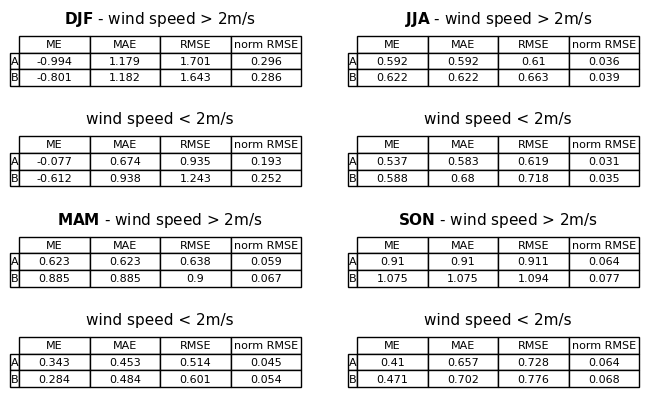

In [75]:
var = 'outTemp'
stagioni = ['DJF', 'MAM', 'JJA', 'SON']
dfC = df_C_year_filt_new[['Datetime','wndSpeed','wndDir','outTemp','Stagione']].copy()

fig, axes = plt.subplots(4, 2, figsize=(2*5 -2, 2*2.5))
#axes = axes_p.flatten() #così accedo con un indice solo alla 2x2
sss = 0
for col in range(2):  # 2 colonne
    for row in range(0, 4, 2):  # 4 righe, ma passo di 2 (0, 2)
        stagione = stagioni[sss]
        minGG_C = dfC.groupby(dfC.Datetime.dt.floor('d'))['outTemp'].min()
        dfC_MIN = pd.DataFrame()
        for date in minGG_C.index:
            dfC_MIN = pd.concat([dfC_MIN, pd.DataFrame(dfC[(dfC.Datetime.dt.floor('d') == date) & (dfC.outTemp == minGG_C[date]) &
                                                        (dfC.wndSpeed >= 2) & (dfC.wndSpeed <= 8) &
                                                        (dfC.wndDir >= 0)&(dfC.wndDir < 360) &
                                                        (dfC.Stagione == stagione)])])
        print(dfC_MIN.shape[0])

        rows = []
        #print("Riferimento "+riferimento)
        indexes = ['A','B']
        for stazione in ['A','B']:
            corr, me, mae, rmse, nrmse = compare_column(dfC_MIN, globals()["df_"+stazione+"_year_filt_new"], var)
            rows.append([round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

        df = pd.DataFrame(rows, index=indexes, columns=['ME', 'MAE', 'RMSE', 'norm RMSE'])
        #display(df)

        ax = axes[row, col]  # primo axes del blocco
        ax.axis('off')
        ax.set_title(r"$\bf{"+ stagione + "}$ - wind speed > 2m/s", loc='center', y=0.85, fontsize=11)
        table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1)

        ##################################### wind < 2m/s
        dfC_MIN = pd.DataFrame()
        for date in minGG_C.index:
            dfC_MIN = pd.concat([dfC_MIN, pd.DataFrame(dfC[(dfC.Datetime.dt.floor('d') == date) & (dfC.outTemp == minGG_C[date]) &
                                                        (dfC.wndSpeed >= 0.5) & (dfC.wndSpeed < 2) &
                                                        (dfC.wndDir >= 0)&(dfC.wndDir < 360) &
                                                        (dfC.Stagione == stagione)])])
        print(dfC_MIN.shape[0])

        rows = []
        #print("Riferimento "+riferimento)
        indexes = ['A','B']
        for stazione in ['A','B']:
            corr, me, mae, rmse, nrmse = compare_column(dfC_MIN, globals()["df_"+stazione+"_year_filt_new"], var)
            rows.append([round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

        df = pd.DataFrame(rows, index=indexes, columns=['ME', 'MAE', 'RMSE', 'norm RMSE'])
        #display(df)

        ax = axes[row+1, col]  # secondo axes del blocco
        ax.axis('off')
        ax.set_title("wind speed < 2m/s", loc='center', y=0.85, fontsize=11)
        table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1)
        sss += 1
plt.savefig('FIGURE/C/min_wind_season_shield.png', dpi=300, bbox_inches='tight')

#minGG_C = dfC_w.groupby(dfC_w.Datetime.dt.floor('d'))['outTemp'].min()

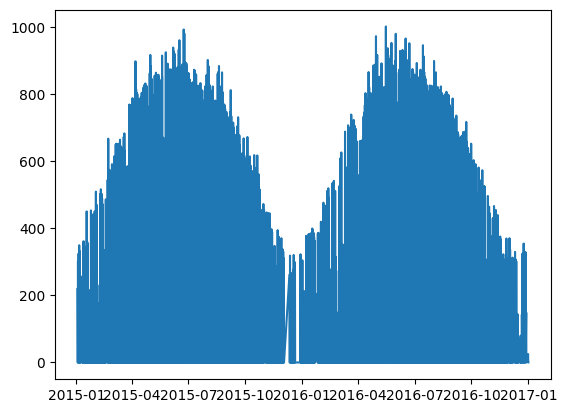

In [97]:
dfA = df_A_year_filt_new[['Datetime','outTemp','totRad','Stagione']][(df_A_year_filt_new.totRad >= 0)&(df_A_year_filt_new.totRad <= 1500)].copy()
dfB = df_B_year_filt_new[['Datetime','outTemp','totRad','Stagione']][(df_B_year_filt_new.totRad >= 0)&(df_B_year_filt_new.totRad <= 1500)].copy()
dfC = df_C_year_filt_new[['Datetime','outTemp','totRad','Stagione']][(df_C_year_filt_new.totRad >= 0)&(df_C_year_filt_new.totRad <= 1500)].copy()

plt.plot(dfA.Datetime, dfA.totRad)

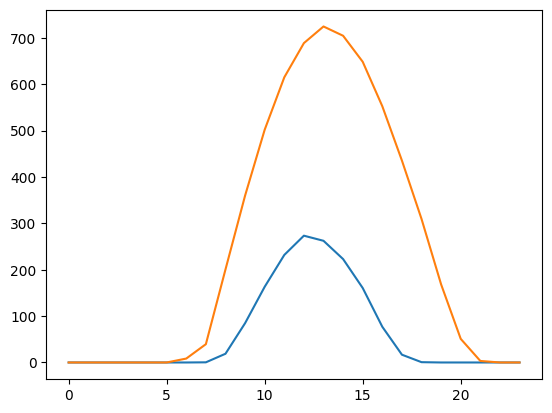

In [98]:
radAvgGG_in = dfA[dfA['Stagione']=='DJF'].groupby(dfA.Datetime.dt.hour)['totRad'].mean()
radAvgGG_es = dfA[dfA['Stagione']=='JJA'].groupby(dfA.Datetime.dt.hour)['totRad'].mean()

plt.plot(radAvgGG_in.index, radAvgGG_in)
plt.plot(radAvgGG_es.index, radAvgGG_es)

193
1
226
95
213
148
218
24


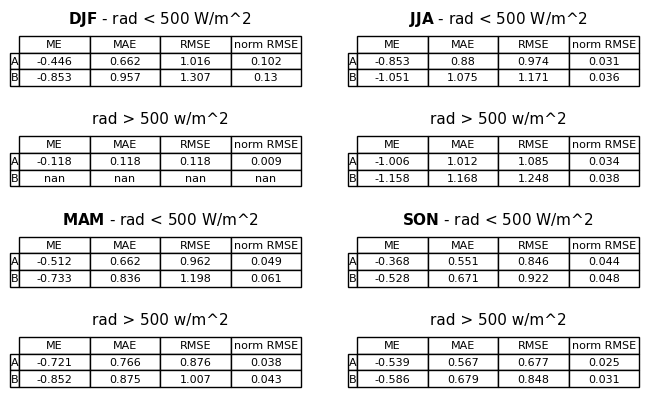

In [89]:
var = 'outTemp'
stagioni = ['DJF', 'MAM', 'JJA', 'SON']

fig, axes = plt.subplots(4, 2, figsize=(2*5 -2, 2*2.5))
#axes = axes_p.flatten() #così accedo con un indice solo alla 2x2
sss = 0
for col in range(2):  # 2 colonne
    for row in range(0, 4, 2):  # 4 righe, ma passo di 2 (0, 2)
        stagione = stagioni[sss]
        maxGG_C = dfC.groupby(dfC.Datetime.dt.floor('d'))['outTemp'].max()
        dfC_MAX = pd.DataFrame()
        for date in maxGG_C.index:
            dfC_MAX = pd.concat([dfC_MAX, pd.DataFrame(dfC[(dfC.Datetime.dt.floor('d') == date) & (dfC.outTemp == maxGG_C[date]) &
                                                        (dfC.totRad >= 0) & (dfC.wndSpeed <= 500) &
                                                        (dfC.Stagione == stagione)])])
        print(dfC_MAX.shape[0])

        rows = []
        #print("Riferimento "+riferimento)
        indexes = ['A','B']
        for stazione in ['A','B']:
            corr, me, mae, rmse, nrmse = compare_column(dfC_MAX, globals()["df_"+stazione+"_year_filt_new"], var)
            rows.append([round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

        df = pd.DataFrame(rows, index=indexes, columns=['ME', 'MAE', 'RMSE', 'norm RMSE'])
        #display(df)

        ax = axes[row, col]  # primo axes del blocco
        ax.axis('off')
        ax.set_title(r"$\bf{"+ stagione + "}$ - rad < 500 W/m^2", loc='center', y=0.85, fontsize=11)
        table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1)

        ##################################### wind < 2m/s
        dfC_MAX = pd.DataFrame()
        for date in maxGG_C.index:
            dfC_MAX = pd.concat([dfC_MAX, pd.DataFrame(dfC[(dfC.Datetime.dt.floor('d') == date) & (dfC.outTemp == maxGG_C[date]) &
                                                        (dfC.totRad > 500) & (dfC.wndSpeed <= 1500) &
                                                        (dfC.Stagione == stagione)])])
        print(dfC_MAX.shape[0])

        rows = []
        #print("Riferimento "+riferimento)
        indexes = ['A','B']
        for stazione in ['A','B']:
            corr, me, mae, rmse, nrmse = compare_column(dfC_MAX, globals()["df_"+stazione+"_year_filt_new"], var)
            rows.append([round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

        df = pd.DataFrame(rows, index=indexes, columns=['ME', 'MAE', 'RMSE', 'norm RMSE'])
        #display(df)

        ax = axes[row+1, col]  # secondo axes del blocco
        ax.axis('off')
        ax.set_title("rad > 500 w/m^2", loc='center', y=0.85, fontsize=11)
        table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1)
        sss += 1
plt.savefig('FIGURE/C/max_wind_season_shield.png', dpi=300, bbox_inches='tight')

#minGG_C = dfC_w.groupby(dfC_w.Datetime.dt.floor('d'))['outTemp'].min()

In [140]:
df_hr = pd.merge(dfA, dfB, on='Datetime', suffixes=('_A','_B'))
df_hr = pd.merge(df_hr, dfC, on='Datetime')
df_hr

,Datetime,outTemp_A,totRad_A,Stagione_A,outTemp_B,totRad_B,Stagione_B,outTemp,totRad,Stagione
0,2015-06-24 10:00:00,18.22,518.0,JJA,20.11,1037.0,JJA,18.282063,592.0,JJA
1,2015-06-24 11:30:00,20.17,667.0,JJA,21.44,1170.0,JJA,20.580138,647.0,JJA
2,2015-06-24 12:00:00,20.06,521.0,JJA,22.06,1116.0,JJA,20.869985,857.0,JJA
3,2015-06-24 13:30:00,22.56,982.0,JJA,22.56,923.0,JJA,23.457907,869.0,JJA
4,2015-06-24 14:00:00,22.94,814.0,JJA,23.39,1036.0,JJA,23.685644,963.0,JJA
...,...,...,...,...,...,...,...,...,...,...
24640,2016-12-31 21:30:00,3.72,0.0,DJF,3.83,0.0,DJF,2.816642,0.0,DJF
24641,2016-12-31 22:00:00,3.61,0.0,DJF,3.67,0.0,DJF,2.578554,0.0,DJF
24642,2016-12-31 22:30:00,3.39,0.0,DJF,3.5,0.0,DJF,2.412927,0.0,DJF
24643,2016-12-31 23:00:00,3.28,0.0,DJF,3.28,0.0,DJF,2.236948,0.0,DJF


Datetime
00:00:00           0.0
00:30:00           0.0
01:00:00           0.0
01:30:00           0.0
02:00:00           0.0
02:30:00           0.0
03:00:00           0.0
03:30:00           0.0
04:00:00           0.0
04:30:00           0.0
05:00:00           0.0
05:30:00      0.081395
06:00:00      1.793774
06:30:00      6.714008
07:00:00     21.330739
07:30:00     30.245614
08:00:00     43.960938
08:30:00     97.931238
09:00:00    185.838583
09:30:00    257.332677
10:00:00      309.6778
10:30:00    359.061144
11:00:00    408.583004
11:30:00    450.595285
12:00:00    473.180039
12:30:00    491.578125
13:00:00    499.344358
13:30:00    502.655706
14:00:00    488.882012
14:30:00    459.592664
15:00:00    430.324324
15:30:00    395.118217
16:00:00    345.893617
16:30:00    296.038685
17:00:00    250.308738
17:30:00    207.157588
18:00:00    166.198842
18:30:00    123.147002
19:00:00      85.27853
19:30:00     53.328155
20:00:00     27.527237
20:30:00     10.947471
21:00:00      2.719844
21

16:00:00
13:30:00


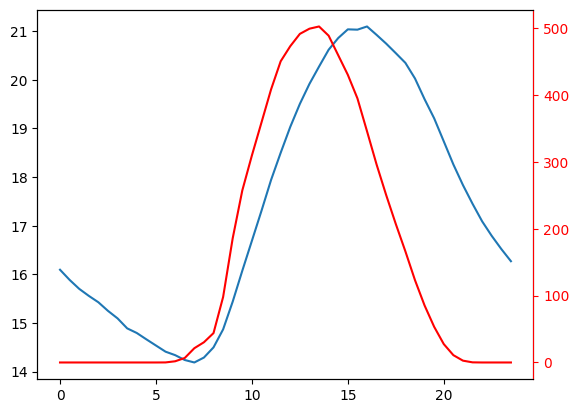

In [145]:
soglia = 0
df_soglia = df_hr[(df_hr.totRad >= soglia)]
tp = df_soglia.groupby(df_soglia.Datetime.dt.time)['outTemp'].mean()
rad = df_soglia.groupby(df_soglia.Datetime.dt.time)['totRad'].mean()
hh_maxTp = tp.index[tp == tp.max()][0]
hh_maxR = rad.index[rad == rad.max()][0]
display(rad)
print(hh_maxTp)
print(hh_maxR)
plt.plot(np.arange(0,24,0.5), tp)

ax2 = plt.gca().twinx()
ax2.spines['right'].set_color('red')
ax2.tick_params(axis='y', colors='red')
ax2.plot(np.arange(0,24,0.5), rad, color='red')

16:00:00
13:30:00


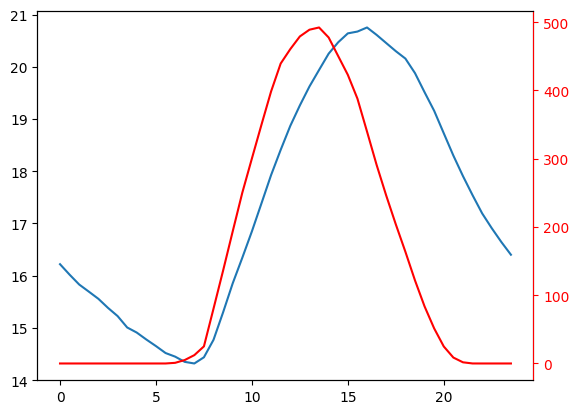

In [ ]:
soglia = 0
df_soglia = df_hr[(df_hr.totRad_A >= soglia)]
tp = df_soglia.groupby(df_soglia.Datetime.dt.time)['outTemp_A'].mean()
rad = df_soglia.groupby(df_soglia.Datetime.dt.time)['totRad_A'].mean()
hh_maxTp = tp.index[tp == tp.max()][0]
hh_maxR = rad.index[rad == rad.max()][0]
print(hh_maxTp)
print(hh_maxR)
plt.plot(np.arange(0,24,0.5), tp)

ax2 = plt.gca().twinx()
ax2.spines['right'].set_color('red')
ax2.tick_params(axis='y', colors='red')
ax2.plot(np.arange(0,24,0.5), rad, color='red')

16:00:00
13:30:00


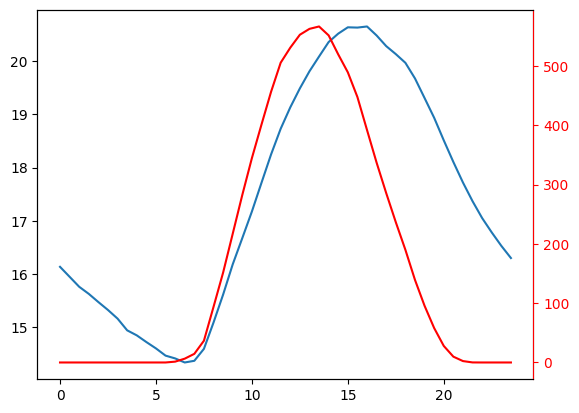

In [143]:
soglia = 0
df_soglia = df_hr[(df_hr.totRad_B >= soglia)]
tp = df_soglia.groupby(df_soglia.Datetime.dt.time)['outTemp_B'].mean()
rad = df_soglia.groupby(df_soglia.Datetime.dt.time)['totRad_B'].mean()
hh_maxTp = tp.index[tp == tp.max()][0]
hh_maxR = rad.index[rad == rad.max()][0]
print(hh_maxTp)
print(hh_maxR)
plt.plot(np.arange(0,24,0.5), tp)

ax2 = plt.gca().twinx()
ax2.spines['right'].set_color('red')
ax2.tick_params(axis='y', colors='red')
ax2.plot(np.arange(0,24,0.5), rad, color='red')

In [ ]:
stagioni = ['DJF','MAM','JJA','SON']
colori = ['blue','green','orange','red']
max = [] #index per le stagioni[a,b,c]
max_std = []

fig_timeseries = plt.figure(figsize=(10, 6))
for i, stagione in enumerate(stagioni):

    plt.subplot(2, 2, i+1)
    tpA = dfA[dfA['Stagione']==stagione].groupby(dfA.Datetime.dt.hour)['outTemp'].mean()
    tpB = dfB[dfB['Stagione']==stagione].groupby(dfB.Datetime.dt.hour)['outTemp'].mean()
    tpC = dfC[dfC['Stagione']==stagione].groupby(dfC.Datetime.dt.hour)['outTemp'].mean()
    #calcolo massimi delle curve
    max.append([tpA.max(), tpB.max(), tpC.max()])
    #calcolo dev del massimo
    ora_max_A = tpA.index[tpA == tpA.max()][0]
    ora_max_B = tpB.index[tpB == tpB.max()][0]
    ora_max_C = tpC.index[tpC == tpC.max()][0]
    tpAstd = A[ (A['Stagione']==stagione) & (A.Datetime.dt.floor('H').dt.hour == ora_max_A) ] ['outTemp'].std()
    tpBstd = B[ (B['Stagione']==stagione) & (B.Datetime.dt.floor('H').dt.hour == ora_max_B) ] ['outTemp'].std()
    tpCstd = C[ (C['Stagione']==stagione) & (C.Datetime.dt.floor('H').dt.hour == ora_max_C) ] ['outTemp'].std()
    max_std.append([tpAstd.item(), tpBstd.item(), tpCstd.item()]) #from float numpy to python

    plt.plot(tpA.index,tpA,color='black')
    plt.plot(tpB.index,tpB,color='red')
    plt.plot(tpC.index,tpC,color='green')
    #plt.ylim(0,1.75)
    #plt.xlim(0,23)
    plt.title(stagione,fontweight='bold')
    if i == 1:
        plt.legend(['Stazione A', 'Stazione B', 'Stazione C'], loc='upper left')
    if i+1 in [1,3]:
        plt.ylabel("Temperatura (°C)")
    if i+1 in [3,4]:
        plt.xlabel("Ora del giorno")
    
    '''ax2 = plt.gca().twinx()
    ax2.spines['right'].set_color('red')
    ax2.tick_params(axis='y', colors='red')
    ax2.plot(np.arange(0,24),tpC,color='red')
#    ax2.set_ylim(0,30)
    if i+1 in [2,4]:
        ax2.set_ylabel('Temp C (°C)',rotation=-90,labelpad=12,color='red')'''

plt.tight_layout()
plt.savefig('FIGURE/C/tempVSore_confronto_noOld.png', dpi=300, bbox_inches='tight')
print(max)
print(max_std)
#DOMANDA, vince errore elevato per dire no oppure vedere su due anni di media un andamento si sovrastima e sottostima per dire si